## House-Keeping

In [1]:
import sys
from pathlib import Path
import warnings

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', font_scale=1.1)

# For notebook: adjust path as needed
DB_PATH = Path("../data/market_data.duckdb").resolve()
MIN_DATE = '2000-01-01'
FEATURE_VERSION = 'v3.1'

CLASS_NAMES = {
    0: 'Class 0: Duds (<=2%)',
    1: 'Class 1: Noise (2-10%)',
    2: 'Class 2: Solid (10-30%)',
    3: 'Class 3: Elite (>30%)'
}
CLASS_COLORS = {0: '#d62728', 1: '#ff7f0e', 2: '#2ca02c', 3: '#1f77b4'}

print("Imports OK")

Imports OK


In [2]:
# check available tables and views
con = duckdb.connect(str(DB_PATH))

tables = con.execute("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main' AND table_type = 'BASE TABLE'
    ORDER BY table_name
""").fetchall()

for (t,) in tables:
    print(f"  {t}")

views = con.execute("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main' AND table_type = 'VIEW'
    ORDER BY table_name
""").fetchall()

for (v,) in views:
    print(f"  {v}")

con.close()


  company_profiles
  d2_training_cache
  earnings_calendar
  feature_catalog
  fundamental_features
  fundamentals
  macro_data
  model_feature_sets
  models
  pipeline_error_log
  pipeline_runs
  price_data
  screener_criteria_versions
  screener_membership
  screener_watchlist
  shares_history
  t1_macro
  t2_regime_scores
  t2_screener_features
  t3_sepa_features
  table_write_log
  ticker_blacklist
  v_d1_candidates
  v_d1_trades
  v_d2_features
  v_d2_hydrated
  v_d2_training
  v_d2r_hydrated
  v_d3_deployment
  v_price_combined
  v_screener_dashboard
  v_sepa_candidates
  v_shares_combined


### Load Data

In [3]:
con = duckdb.connect(str(DB_PATH))

models = con.execute(f"""
    SELECT *
    FROM models
""").df()

model_feature_sets = con.execute(f"""
    SELECT *
    FROM model_feature_sets
""").df()

v_d2_training = con.execute(f"""
    SELECT *
    FROM v_d2_training
    ORDER BY date, ticker
""").df()

con.close()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [4]:
from IPython.display import display, HTML
print("Models Table:")
display(models.head(3))
print("-" * 50)
print("\nModel Feature Sets Table:")
display(model_feature_sets.head(3))
print("-" * 50)
print("\nTraining View (v_d2_training):")
display(v_d2_training.tail(3))

Models Table:


,version_id,status_flag,specs_json,feature_version,training_date,dataset_rows,rmse,mae,r2,spearman_corr,artifacts_path,created_at,updated_at,accuracy,weighted_f1,macro_f1,feature_set_id,git_sha,model_type
0,M01_baseline_20260315_133129,test,"{""features"": [""close_above_sma200"", ""price_vs_...",v3.1,2026-03-15,1754,NaN,NaN,NaN,NaN,models/artifacts/M01_baseline_20260315_133129,2026-03-15 13:31:29.415650,2026-03-15 13:31:29.415650,NaN,NaN,NaN,None,None,classifier
1,M01_baseline_v0.1,prod,"{""features"": [""close_above_sma200"", ""price_vs_...",v3.1,2026-04-10,1754,NaN,NaN,NaN,NaN,models\artifacts\M01_baseline_v0.1,2026-04-10 20:43:23.122666,2026-04-10 20:43:23.122666,0.670455,0.58196,0.247511,fs_m01_baseline_v0.1,0bc18e9e04004910c39ba0618787e6313e34e548,classifier


--------------------------------------------------

Model Feature Sets Table:


,feature_set_id,feature_name,feature_group,ordinal
0,fs_m01_baseline_v0.1,close_above_sma200,Moving_Averages,0
1,fs_m01_baseline_v0.1,price_vs_sma_50,Moving_Averages,1
2,fs_m01_baseline_v0.1,price_vs_sma_150,Moving_Averages,2


--------------------------------------------------

Training View (v_d2_training):


,ticker,date,feature_version,open,high,low,close,volume,sma_20,sma_50,...,return_at_exit,mae_date,mfe_date,sepa_exit_date,holding_days,days_observed,sl_triggered,sl_date,sl_exit_date,sl_pct
38102,TTMI,2026-04-24,v3.1,136.720001,149.080002,136.160004,149.009995,2667300,113.467999,105.002400,...,0.0,NaT,2026-04-24,2026-04-24,0,1,False,NaT,NaT,NaN
38103,TTMI,2026-04-24,v3.1,136.720001,149.080002,136.160004,149.009995,2667300,113.467999,105.002400,...,0.0,NaT,2026-04-24,2026-04-24,0,1,False,NaT,NaT,NaN
38104,UVE,2026-04-24,v3.1,37.500000,39.529999,35.849998,39.480000,524500,34.605000,33.975449,...,0.0,NaT,2026-04-24,2026-04-24,0,1,False,NaT,NaT,NaN


## Feature Engineering

In [5]:
df = v_d2_training.copy()

print(f"Loaded {len(df):,} rows | {df['ticker'].nunique()} tickers")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Columns: {len(df.columns)}")

Loaded 38,105 rows | 2686 tickers
Date range: 2001-01-03 00:00:00 to 2026-04-24 00:00:00
Columns: 219


#### check features not in feature set

In [6]:
# Feature Groups hard-coded in training file for v0.1
FEATURE_GROUPS = {
    "Moving_Averages": [
        'close_above_sma200', 'price_vs_sma_50', 'price_vs_sma_150', 'price_vs_sma_200',
        'sma_50_slope', 'price_vs_sma_50_delta', 'price_vs_sma_150_delta', 'price_vs_sma_200_delta'
    ],
    "Momentum_RS": [
        'rs_line_uptrend', 'rs_line_delta', 'rs_line_lag_delta', 'rs_rating', 'rs', 'rs_ma',
        'rs_delta', 'rs_ma_delta', 'mom_21d', 'mom_63d', 'mom_126d', 'mom_189d', 'mom_252d',
        'rs_velocity', 'price_accel_10d', 'rs_sector_rank', 'rs_vs_sector', 'sector_momentum',
        'rs_industry_rank', 'rs_vs_industry', 'industry_momentum'
    ],
    "Core_Volume": [
        'vol_ratio', 'dry_up_volume', 'dry_up_volume_delta', 'turnover',
        'volume_acceleration', 'return_1d', 'return_5d'
    ],
    "Volatility_Ranges": [
        'natr', 'natr_delta', 'atr_delta', 'vcp_ratio', 'vcp_ratio_delta',
        'consolidation_width', 'consolidation_width_delta', 'consolidation_duration',
        'dist_from_52w_high', 'dist_from_52w_high_delta',
        'dist_from_52w_low', 'dist_from_52w_low_delta',
        'low_52w_delta', 'high_52w_delta',
        'dist_from_20d_high', 'dist_from_20d_high_delta', 'highest_high_20d_delta',
        'dist_from_20d_low', 'dist_from_20d_low_delta', 'lowest_low_20d_delta'
    ],
    "Technical_Oscillators": [
        'rsi_14', 'rsi_14_delta', 'is_green_day', 'green_days_ratio_20d', 'breakout',
        'breakout_momentum', 'immediate_thrust'
    ],
    "Fundamentals": [
        'eps_diluted', 'revenue_growth_yoy', 'eps_growth_yoy', 'net_income_growth_yoy',
        'eps_accel', 'revenue_accel', 'revenue_cagr_3y', 'eps_stability_score',
        'debt_to_equity', 'current_ratio', 'gross_margin', 'operating_margin', 'roe', 'roa',
        'fcf_margin', 'earnings_quality_score', 'gross_margin_trend', 'days_since_report',
        'pe_ratio', 'ps_ratio', 'pb_ratio'
    ],
    "Fast_Alphas": [
        'alpha001', 'alpha002', 'alpha004', 'alpha006', 'alpha009', 'alpha011', 'alpha012',
        'alpha013', 'alpha015', 'alpha041', 'alpha046', 'alpha049', 'alpha054', 'alpha060',
        'alpha101'
    ],
    "M03_Regime": [
        'm03_score', 'm03_pillar_trend', 'm03_pillar_liq', 'm03_pillar_risk',
        'm03_delta_5d', 'm03_delta_20d', 'm03_regime_vol'
    ]
}

uppercase_cols = [col for col in df.columns if not col.islower()]
if uppercase_cols:
    print(f"⚠️ Found {len(uppercase_cols)} columns with uppercase letters:")
    print(uppercase_cols)
else:
    print("✅ All columns are completely lowercase.")

# Flatten the feature groups and standardize to lowercase for safe comparison
all_model_features = [feat.lower() for grp in FEATURE_GROUPS.values() for feat in grp]

feature_set_id = models[models['status_flag']=='prod']['feature_set_id'].values[0]
prod_feature_set = model_feature_sets[model_feature_sets['feature_set_id'] == feature_set_id]

# check model_feature_sets coverage
prod_feature_set_set = set([f.lower() for f in prod_feature_set['feature_name'].values])
actual_feature_set = set(all_model_features)

missing_from_prod = actual_feature_set - prod_feature_set_set
extra_from_prod = prod_feature_set_set - actual_feature_set

print(f"❌ Missing from DB ({len(missing_from_prod)} features):")
print(sorted(list(missing_from_prod)))

print(f"\n⚠️ In DB but missing from FEATURE_GROUPS ({len(extra_from_prod)} features):")
print(sorted(list(extra_from_prod)))

# Check Training data Coverage: Are all model features present in the dataframe?
df_columns_lower = {col.lower(): col for col in df.columns}
missing_from_df = [feat for feat in all_model_features if feat not in df_columns_lower]

print("=" * 60)
print(f"1. COVERAGE CHECK")
print("=" * 60)
print(f"Total features defined in FEATURE_GROUPS: {len(all_model_features)}")
if missing_from_df:
    print(f"❌ Missing features in df ({len(missing_from_df)}):")
    print(missing_from_df)
else:
    print("✅ Full coverage: All model features are present in the DataFrame.")

# 3. Find what's in the DataFrame but NOT in FEATURE_GROUPS
df_not_in_model = [orig_col for lower_col, orig_col in df_columns_lower.items() 
                   if lower_col not in all_model_features]

print("\n" + "=" * 60)
print(f"2. UNUSED COLUMNS (In df but NOT in FEATURE_GROUPS)")
print("=" * 60)
print(f"Total unused columns: {len(df_not_in_model)}")
print(sorted(df_not_in_model))


⚠️ Found 7 columns with uppercase letters:
['RS_Universe_Rank', 'RS_Sector_Rank', 'RS_vs_Sector', 'Sector_Momentum', 'RS_Industry_Rank', 'RS_vs_Industry', 'Industry_Momentum']
❌ Missing from DB (0 features):
[]

⚠️ In DB but missing from FEATURE_GROUPS (0 features):
[]
1. COVERAGE CHECK
Total features defined in FEATURE_GROUPS: 106
❌ Missing features in df (1):
['atr_delta']

2. UNUSED COLUMNS (In df but NOT in FEATURE_GROUPS)
Total unused columns: 114
['RS_Universe_Rank', 'adr_20d', 'alpha008', 'alpha019', 'alpha051', 'atr_14', 'atr_20d', 'atr_pct_chg', 'close', 'consolidation_width_pct_chg', 'date', 'days_observed', 'dist_from_20d_high_pct_chg', 'dist_from_20d_low_pct_chg', 'dist_from_52w_high_pct_chg', 'dist_from_52w_low_pct_chg', 'dollar_volume_avg_20', 'dry_up_volume_pct_chg', 'ema_100', 'ema_200', 'ema_21', 'ema_21_50_ratio', 'ema_50', 'ema_50_100_ratio', 'ema_8', 'ema_8_21_ratio', 'entry_date', 'entry_price', 'exit_date', 'exit_price', 'feature_version', 'fiscal_period', 'fundam

### EMA Ratios

In [7]:
# Price-to-EMA ratios (how far price is from each EMA)
df['price_vs_ema_8'] = (df['close'] / df['ema_8'] - 1) * 100
# df['price_vs_ema_21'] = (df['close'] / df['ema_21'] - 1) * 100
# df['price_vs_ema_50'] = (df['close'] / df['ema_50'] - 1) * 100
# df['price_vs_ema_100'] = (df['close'] / df['ema_100'] - 1) * 100
# df['price_vs_ema_200'] = (df['close'] / df['ema_200'] - 1) * 100

# EMA stacking: short-over-long ratios (measures trend alignment)
df['ema_8_21_ratio'] = (df['ema_8'] / df['ema_21'] - 1) * 100
df['ema_21_50_ratio'] = (df['ema_21'] / df['ema_50'] - 1) * 100
df['ema_50_100_ratio'] = (df['ema_50'] / df['ema_100'] - 1) * 100
df['ema_100_200_ratio'] = (df['ema_100'] / df['ema_200'] - 1) * 100

# EMA stack score: how many short EMAs are above long EMAs (0-4 scale)
df['ema_stack_score'] = (
    (df['ema_8'] > df['ema_21']).astype(int) +
    (df['ema_21'] > df['ema_50']).astype(int) +
    (df['ema_50'] > df['ema_100']).astype(int) +
    (df['ema_100'] > df['ema_200']).astype(int)
)

EMA_FEATURES = [
    'price_vs_ema_8', 
    # 'price_vs_ema_21', 
    # 'price_vs_ema_50',
    # 'price_vs_ema_100', 
    # 'price_vs_ema_200',
    'ema_8_21_ratio', 
    'ema_21_50_ratio', 
    'ema_50_100_ratio', 
    'ema_100_200_ratio',
    'ema_stack_score'
]

print(f"Created {len(EMA_FEATURES)} EMA features")
print(df[EMA_FEATURES].describe().round(2).to_string())


Created 6 EMA features
       price_vs_ema_8  ema_8_21_ratio  ema_21_50_ratio  ema_50_100_ratio  ema_100_200_ratio  ema_stack_score
count        38105.00        38105.00         38105.00          38105.00           38105.00         38105.00
mean             5.24            2.24             2.61              3.90               5.63             3.87
std              5.44            2.25             2.82              2.86               3.99             0.40
min              0.15           -4.09            -9.97             -4.37             -63.67             0.00
25%              2.66            1.07             1.07              2.11               3.29             4.00
50%              4.01            1.78             2.08              3.20               4.89             4.00
75%              6.18            2.75             3.43              4.86               7.29             4.00
max            260.36           83.66            71.10             40.52              38.55             4

### Momentum

In [8]:
df['mom_slope_21_63'] = df['mom_21d'] - df['mom_63d']
df['mom_slope_63_126'] = df['mom_63d'] - df['mom_126d']
df['mom_slope_126_252'] = df['mom_126d'] - df['mom_252d']

df['mom_21d_vol_adj'] = df['mom_21d'] / df['return_1d'].rolling(window=21).std()

### SMA

In [9]:
# Calculate adjacent structural crossover ratios
# Using the math trick: Ratio = (price_vs_sma_slow + 100) / (price_vs_sma_fast + 100) - 1
df['sma_ratio_50_150'] = ((df['price_vs_sma_150'] + 100) / (df['price_vs_sma_50'] + 100) - 1) * 100
df['sma_ratio_150_200'] = ((df['price_vs_sma_200'] + 100) / (df['price_vs_sma_150'] + 100) - 1) * 100
df['price_vs_sma_50_vol_adj'] = df['price_vs_sma_50'] / df['return_1d'].rolling(window=50).std()

In [10]:
df['gap_risk_ratio'] = df['natr'] / df['adr_20d']

### Warm-up clipping

In [11]:
# Drop each ticker's leading rows where any sentinel is NULL.
# Global date clip (MIN_DATE) is applied first as a data-quality floor
# (C11 breakout_ok fix only backfilled to 2019).
# Per-ticker clip handles tickers that entered the universe later —
# a 2022 IPO still has 252-day RS warmup regardless of the global floor.

WARMUP_SENTINELS = ['rs', 'm03_score', 'dist_from_20d_high_delta']

df['date'] = pd.to_datetime(df['date'])

# Step 1: global data-quality floor
pre_clip = len(df)
df = df[df['date'] >= MIN_DATE].copy()
print(f"Global floor ({MIN_DATE}): {pre_clip:,} -> {len(df):,} rows")

# Step 2: per-ticker warmup clip — drop each ticker's leading NULL rows
df = df.sort_values(['ticker', 'date'])
sentinel_null = df[WARMUP_SENTINELS].isnull().any(axis=1)

# cumsum trick: within each ticker, rows before the first valid row have
# cumsum==0 on the inverted mask — drop those
is_valid = ~sentinel_null
df['_cumvalid'] = is_valid.groupby(df['ticker']).cumsum()
post_clip = len(df)
df = df[df['_cumvalid'] > 0].drop(columns='_cumvalid').copy()
print(f"Per-ticker warmup clip: {post_clip:,} -> {len(df):,} rows (removed {post_clip - len(df):,})")

# Verify residual null rate
residual = df[WARMUP_SENTINELS].isnull().mean()
print(f"\nResidual null rates after clip:")
for col, rate in residual.items():
    status = "✅" if rate < 0.001 else "⚠️"
    print(f"  {status} {col}: {rate:.4f}")
print(f"\nDate range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Tickers retained: {df['ticker'].nunique()}")


Global floor (2000-01-01): 38,105 -> 38,105 rows
Per-ticker warmup clip: 38,105 -> 35,536 rows (removed 2,569)

Residual null rates after clip:
  ✅ rs: 0.0000
  ✅ m03_score: 0.0000
  ✅ dist_from_20d_high_delta: 0.0000

Date range: 2003-07-21 to 2026-04-24
Tickers retained: 2587


### Gather Features

In [12]:
df.columns = df.columns.str.lower()

METADATA_COLS = [
    'ticker', 'date', 'feature_version', 'trade_id', 'is_new_trigger', 
    'company_name', 'fundamental_filing_date', 'fiscal_period', 'entry_date', 'ingested_at', 'updated_at'
]

RAW_PRICE_COLS = ['open', 'high', 'low', 'close', 'volume', 'entry_price', 'exit_price']

LEAKAGE_COLS = [
    'mfe_pct', 'mfe_date', 
    'mae_pct', 'mae_date', 
    'return_at_exit', 'return_pct',
    'exit_date', 'exit_price', 'sepa_exit_date', 
    'holding_days', 'days_observed',
    'sl_triggered', 'sl_date', 'sl_exit_date', 'sl_pct'
]

EXCLUDE_SET = set(METADATA_COLS + RAW_PRICE_COLS + LEAKAGE_COLS)
forbidden_patterns = ['mfe', 'mae', 'return_at_exit', 'final_', 'outcome_', 'exit_', 'result_']
safe_feature_list = []
for col in df.columns:
    # Rule 1: Not in our explicit ban list
    if col in EXCLUDE_SET:
        continue
        
    # Rule 2: Doesn't trigger any string pattern leakage traps
    if any(pattern in col for pattern in forbidden_patterns):
        continue
        
    # YOU NEED THIS LINE RIGHT HERE:
    safe_feature_list.append(col)
print(f"Total columns in raw df: {len(df.columns)}")
print(f"Total SAFE predictive features: {len(safe_feature_list)}")

Total columns in raw df: 224
Total SAFE predictive features: 194


In [13]:
# Group features by category for the null audit
prod_feature_set = prod_feature_set.sort_values('ordinal') 
# Base groups from production
FEATURE_GROUPS = prod_feature_set.groupby('feature_group')['feature_name'].apply(list).to_dict()
FEATURE_GROUPS['EMA_Ratios'] = EMA_FEATURES

# 1. Create a flattened, lowercased set of everything we already have grouped
known_features = set()
for category_features in FEATURE_GROUPS.values():
    for f in category_features:
        known_features.add(f.lower())
# 2. Extract anything from safe_feature_list that wasn't in our known groups
new_features = [feat for feat in safe_feature_list if feat.lower() not in known_features]
# 3. Assign the newly discovered features to their own dedicated group
FEATURE_GROUPS['New_Features'] = new_features
print(f"Grouped {len(new_features)} new features to study")

Grouped 83 new features to study


### Quality Check: Missing Data

In [14]:
null_summary = []
for group_name, features in FEATURE_GROUPS.items():
    present = [f for f in features if f in df.columns]
    missing_cols = [f for f in features if f not in df.columns]
    if missing_cols:
        print(f"\n  [{group_name}] MISSING COLUMNS: {missing_cols}")
    if present:
        null_rates = df[present].isnull().mean()
        worst = null_rates[null_rates > 0].sort_values(ascending=False)
        null_summary.append({
            'group': group_name,
            'n_features': len(present),
            'avg_null_pct': null_rates.mean() * 100,
            'max_null_pct': null_rates.max() * 100,
            'worst_feature': worst.index[0] if len(worst) > 0 else '-'
        })

null_df = pd.DataFrame(null_summary)
print(null_df.to_string(index=False))




  [Volatility_Ranges] MISSING COLUMNS: ['atr_delta']
                group  n_features  avg_null_pct  max_null_pct           worst_feature
          Core_Volume           7      0.000000      0.000000                       -
          Fast_Alphas          15      0.000000      0.000000                       -
         Fundamentals          21      9.319322     12.604120         revenue_cagr_3y
           M03_Regime           7      0.000000      0.000000                       -
          Momentum_RS          21      0.035913      0.481202       rs_line_lag_delta
      Moving_Averages           8      0.000704      0.005628   price_vs_sma_50_delta
Technical_Oscillators           7      0.013668      0.047839                  rsi_14
    Volatility_Ranges          19      0.001481      0.019698 dist_from_20d_low_delta
           EMA_Ratios           6      0.000000      0.000000                       -
         New_Features          83      2.977330     48.367852            peg_adjusted


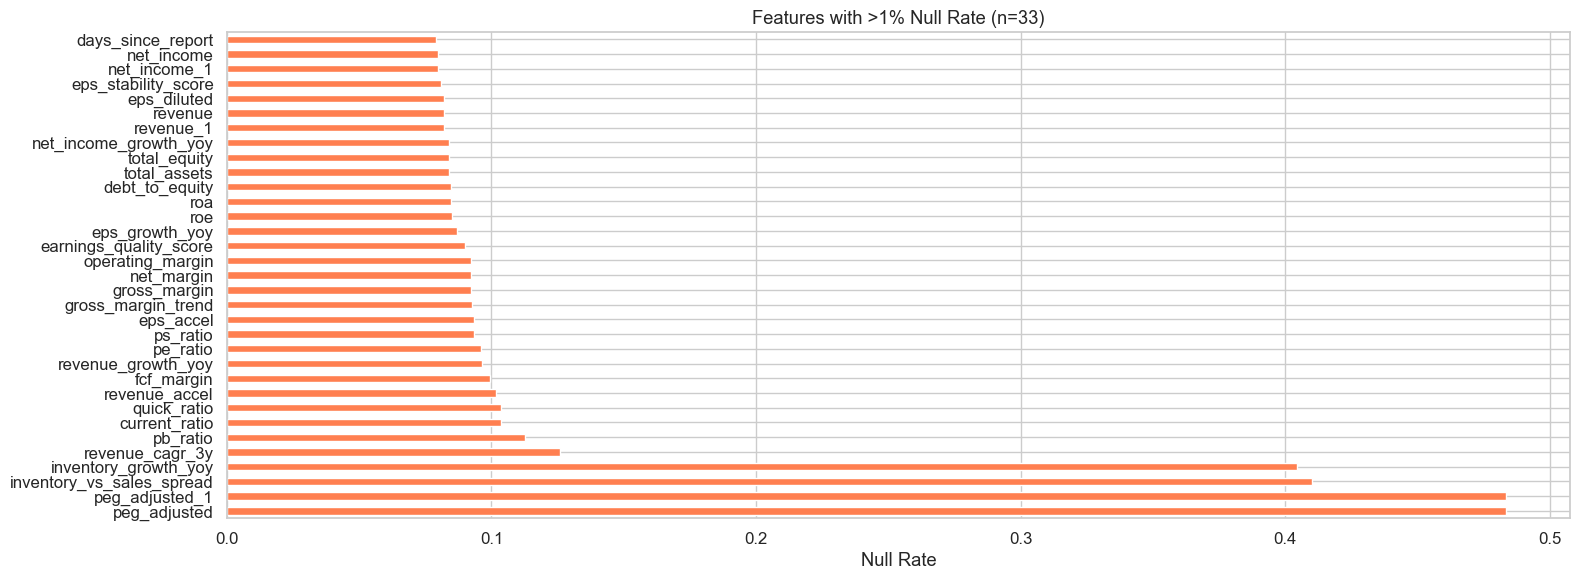

In [15]:
# plot null rates
fig, ax = plt.subplots(figsize=(16, 6))
all_features_flat = [f for feats in FEATURE_GROUPS.values() for f in feats if f in df.columns]
null_pcts = df[all_features_flat].isnull().mean().sort_values(ascending=False)
high_null = null_pcts[null_pcts > 0.01]

if len(high_null) > 0:
    high_null.plot.barh(ax=ax, color='coral')
    ax.set_xlabel('Null Rate')
    ax.set_title(f'Features with >1% Null Rate (n={len(high_null)})')
    plt.tight_layout()
    plt.show()
else:
    print("All features have <1% null rate")
    plt.close()


In [16]:
high_null

peg_adjusted                 0.483679
peg_adjusted_1               0.483650
inventory_vs_sales_spread    0.410288
inventory_growth_yoy         0.404660
revenue_cagr_3y              0.126041
pb_ratio                     0.112787
current_ratio                0.103416
quick_ratio                  0.103416
revenue_accel                0.101531
fcf_margin                   0.099505
revenue_growth_yoy           0.096240
pe_ratio                     0.095903
ps_ratio                     0.093342
eps_accel                    0.093229
gross_margin_trend           0.092751
gross_margin                 0.092301
net_margin                   0.092301
operating_margin             0.092301
earnings_quality_score       0.090106
eps_growth_yoy               0.087123
roe                          0.085069
roa                          0.084731
debt_to_equity               0.084675
total_assets                 0.084112
total_equity                 0.084112
net_income_growth_yoy        0.083887
revenue_1   

### [Placeholder] Address Missing Values - need to fix dist_from_20d_high_delta
Rerun sequence:
1. compute_t2_screener_features(start_date='2000-01-01')  # DELETE + reinsert
2. backfill_t3_sepa_features.py --start 2000-01-01        # DELETE + reinsert t3
3. ViewManager.create_all()                                # refresh views
4. refresh_training_cache.py                               # refresh d2_training_cache

#### ** -> now go back and check for missing again

### Target Construction & Distribution

CLASS DISTRIBUTION
  Class 0: Duds (<=2%):  6,545 (18.4%)
  Class 1: Noise (2-10%): 14,754 (41.5%)
  Class 2: Solid (10-30%): 10,233 (28.8%)
  Class 3: Elite (>30%):  4,004 (11.3%)
  Total                         : 35,536


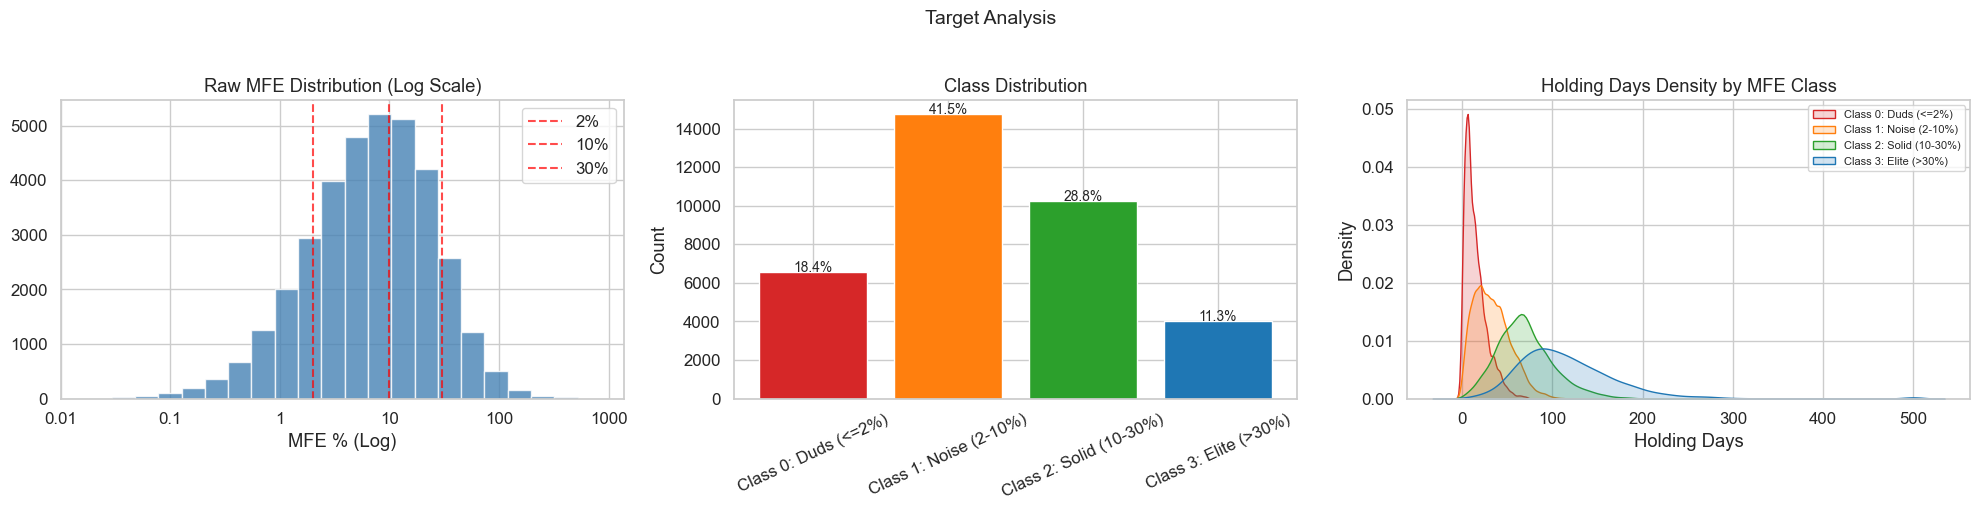

In [17]:
conditions = [
    (df['mfe_pct'] <= 2.0),
    (df['mfe_pct'] > 2.0) & (df['mfe_pct'] <= 10.0),
    (df['mfe_pct'] > 10.0) & (df['mfe_pct'] <= 30.0),
    (df['mfe_pct'] > 30.0)
]
choices = [0, 1, 2, 3]
df['target_class'] = np.select(conditions, choices, default=0).astype(int)
df['target_label'] = df['target_class'].map(CLASS_NAMES)

# Class distribution table
class_counts = df['target_class'].value_counts().sort_index()
class_pcts = df['target_class'].value_counts(normalize=True).sort_index() * 100

print("=" * 50)
print("CLASS DISTRIBUTION")
print("=" * 50)
for cls in sorted(CLASS_NAMES.keys()):
    print(f"  {CLASS_NAMES[cls]}: {class_counts.get(cls, 0):>6,} ({class_pcts.get(cls, 0):.1f}%)")
print(f"  {'Total':<30s}: {len(df):>6,}")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 5a. Raw MFE distribution (continuous)
# axes[0].hist(df['mfe_pct'].clip(-10, 80), bins=80, color='steelblue', edgecolor='white', alpha=0.8)
# for edge in [2, 10, 30]:
#     axes[0].axvline(edge, color='red', linestyle='--', alpha=0.7, label=f'{edge}%')
# axes[0].set_title('Raw MFE Distribution (clipped to [-10, 80])')
# axes[0].set_xlabel('MFE %')
# axes[0].legend()

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# 1. Filter out 0 or negative values to prevent log(0) errors
mfe_data = df.loc[df['mfe_pct'] > 0, 'mfe_pct']
# 2. Create pure logarithmic bins from the min to the max value
bins = np.logspace(np.log10(mfe_data.min()), np.log10(mfe_data.max()), 80)
# 3. Plot the histogram
axes[0].hist(mfe_data, bins=bins, color='steelblue', edgecolor='white', alpha=0.8)
# 4. Set the x-axis to a pure log scale
axes[0].set_xscale('log')
# 5. Fix the limits so it doesn't render empty space on the left
axes[0].set_xlim(left=0.01, right=mfe_data.max())
# 6. Formatting: Use standard log ticks (1, 10, 100, etc.) without decimals
formatter = ticker.FuncFormatter(lambda y, _: '{:g}'.format(y))
axes[0].xaxis.set_major_formatter(formatter)
# Add the boundary lines
for edge in [2, 10, 30]:
    axes[0].axvline(edge, color='red', linestyle='--', alpha=0.7, label=f'{edge}%')
    
axes[0].set_title('Raw MFE Distribution (Log Scale)')
axes[0].set_xlabel('MFE % (Log)')
axes[0].legend()

# 5b. Class bar chart
bars = axes[1].bar(
    [CLASS_NAMES[c] for c in sorted(CLASS_NAMES)],
    [class_counts.get(c, 0) for c in sorted(CLASS_NAMES)],
    color=[CLASS_COLORS[c] for c in sorted(CLASS_NAMES)]
)
for bar, cls in zip(bars, sorted(CLASS_NAMES)):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{class_pcts.get(cls, 0):.1f}%', ha='center', fontsize=10)
axes[1].set_title('Class Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=25)

# 5c. Holding days density by class
for cls in sorted(CLASS_NAMES.keys()):
    subset = df[df['target_class'] == cls]
    if len(subset) > 0 and 'holding_days' in df.columns:
        sns.kdeplot(subset['holding_days'].clip(0, 500), ax=axes[2],
                    label=CLASS_NAMES[cls], color=CLASS_COLORS[cls],
                    fill=True, alpha=0.2, common_norm=False)
axes[2].set_title('Holding Days Density by MFE Class')
axes[2].set_xlabel('Holding Days')
axes[2].legend(fontsize=8)

plt.suptitle('Target Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


Notes:
1. MFE is ~ log-normally distriubuted
2. class imbalance, model tendencyt to just guess Noise or Solid
3. higher MFE usually coupled with longer hold times

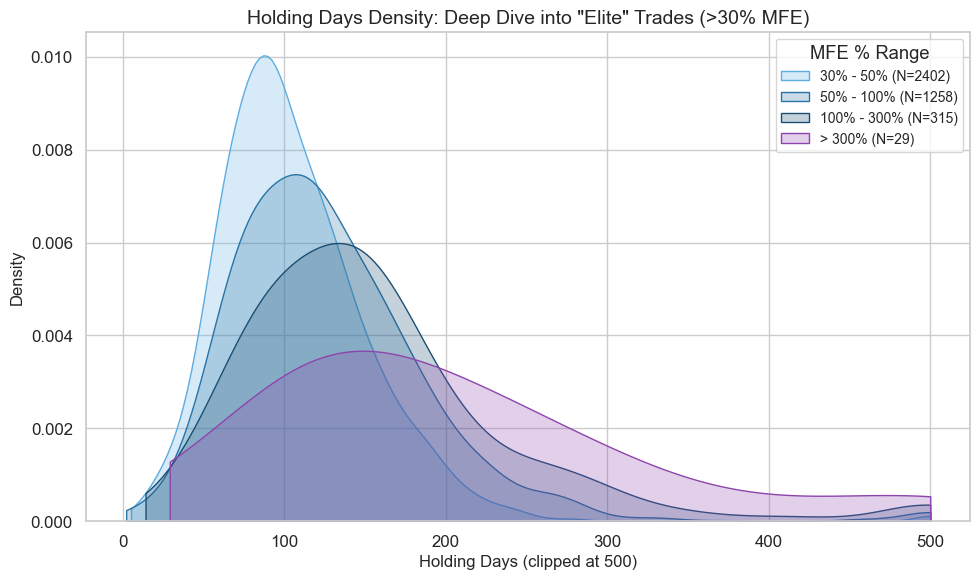

In [18]:
# 1. Filter for the Elite records only
elite_df = df[df['mfe_pct'] > 30].copy()

# 2. Define sub-segments for Elite returns
elite_bins = [30, 50, 100, 300, np.inf]
elite_labels = ['30% - 50%', '50% - 100%', '100% - 300%', '> 300%']

# Create a new categorical column for these segments
elite_df['elite_segment'] = pd.cut(elite_df['mfe_pct'], bins=elite_bins, labels=elite_labels)

# 3. Set up the figure
fig, ax = plt.subplots(figsize=(10, 6))
sns.set_style("whitegrid")

# Assign a custom color palette for differentiation (light blue to deep purple)
segment_colors = ['#5dade2', '#2874a6', '#1b4f72', '#8e44ad']

# 4. Plot the holding days KDE for each sub-segment
for idx, segment in enumerate(elite_labels):
    subset = elite_df[elite_df['elite_segment'] == segment]
    if len(subset) > 0 and 'holding_days' in df.columns:
        sns.kdeplot(subset['holding_days'].clip(0, 500), ax=ax,
                    label=f"{segment} (N={len(subset)})", color=segment_colors[idx],
                    fill=True, alpha=0.25, common_norm=False, cut=0)

# 5. Formatting
ax.set_title('Holding Days Density: Deep Dive into "Elite" Trades (>30% MFE)', fontsize=14)
ax.set_xlabel('Holding Days (clipped at 500)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(title='MFE % Range', fontsize=10)

plt.tight_layout()
plt.show()


Notes:
- confirmed higher MFE comes with longer holding period

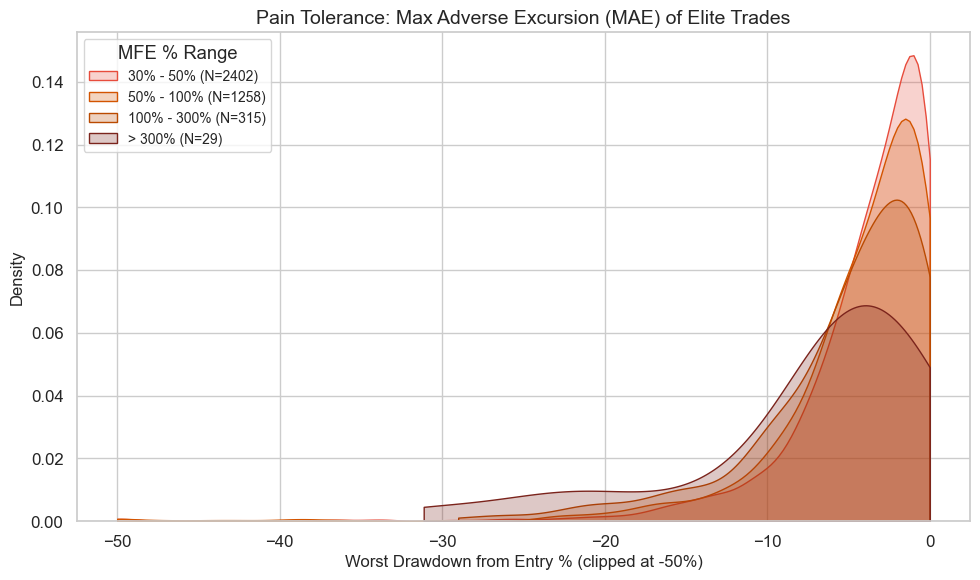

In [19]:
# 1. Filter for Elite records and build segments
elite_df = df[df['mfe_pct'] > 30].copy()
elite_bins = [30, 50, 100, 300, np.inf]
elite_labels = ['30% - 50%', '50% - 100%', '100% - 300%', '> 300%']
elite_df['elite_segment'] = pd.cut(elite_df['mfe_pct'], bins=elite_bins, labels=elite_labels)

# 2. Set up the figure with reddish hues for drawdown
fig, ax = plt.subplots(figsize=(10, 6))
sns.set_style("whitegrid")
segment_colors = ['#e74c3c', '#d35400', '#ba4a00', '#7b241c'] 

# 3. Plot MAE density for each segment
# We use cut=0 to stop the KDE from smoothly blurring into positive numbers
if 'mae_pct' in elite_df.columns:
    for idx, segment in enumerate(elite_labels):
        subset = elite_df[elite_df['elite_segment'] == segment]
        if len(subset) > 0:
            sns.kdeplot(subset['mae_pct'].clip(lower=-50, upper=0), ax=ax, 
                        label=f"{segment} (N={len(subset)})", color=segment_colors[idx],
                        fill=True, alpha=0.25, common_norm=False, cut=0)

    # Formatting
    ax.set_title('Pain Tolerance: Max Adverse Excursion (MAE) of Elite Trades', fontsize=14)
    # Assuming AE is recorded as negative percentages. (If yours is positive, change clip and label)
    ax.set_xlabel('Worst Drawdown from Entry % (clipped at -50%)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.legend(title='MFE % Range', fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("Warning: 'mae_pct' column not found in your dataframe!")


Notes:
- there can be large drawdowns since entering a superperformer trade
- 15% is a good gauge
- for the ones with larger drawdown, it's because they had even stronger breakout, absorbing this shock
- there should be a way to evaluate the cushion a ticker has, so to better estimate the SL point, likely atr for the past few days, and can be a function of holding period.

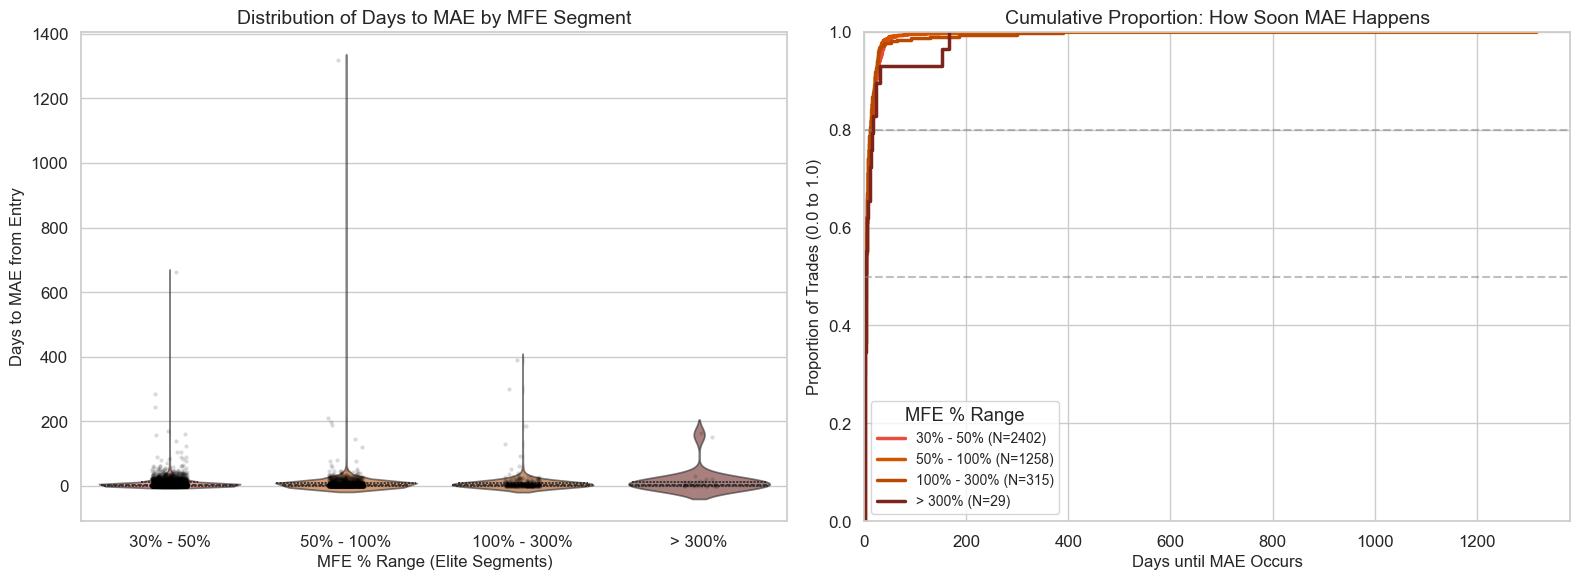

In [20]:
# 1. Ensure dates are datetime and compute the days to MAE
# (Change 'date' to your actual entry date column if it has a different name like 'entry_date')
elite_df['date'] = pd.to_datetime(elite_df['date'])
elite_df['mae_date'] = pd.to_datetime(elite_df['mae_date'])
elite_df['days_to_mae'] = (elite_df['mae_date'] - elite_df['date']).dt.days

# Drop records where we couldn't calculate days just to be safe
plot_df = elite_df.dropna(subset=['days_to_mae', 'elite_segment'])

# 2. Set up a 1x2 figure with the reddish hues for drawdown
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_style("whitegrid")
segment_colors = ['#e74c3c', '#d35400', '#ba4a00', '#7b241c'] 

# --- Subplot 1: Violin Plot (Density & Median) ---
sns.violinplot(
    data=plot_df, 
    x='elite_segment', 
    y='days_to_mae', 
    order=elite_labels,
    palette=segment_colors,
    inner="quartile",
    alpha=0.6,
    ax=axes[0]
)
# Add a faint stripplot on top to show actual point clusters
sns.stripplot(
    data=plot_df, 
    x='elite_segment', 
    y='days_to_mae', 
    order=elite_labels,
    color='black', 
    alpha=0.15, 
    size=3,
    jitter=True,
    ax=axes[0]
)
axes[0].set_title('Distribution of Days to MAE by MFE Segment', fontsize=14)
axes[0].set_xlabel('MFE % Range (Elite Segments)', fontsize=12)
axes[0].set_ylabel('Days to MAE from Entry', fontsize=12)

# --- Subplot 2: ECDF Plot (How Soon?) ---
for idx, segment in enumerate(elite_labels):
    subset = plot_df[plot_df['elite_segment'] == segment]
    if len(subset) > 0:
        sns.ecdfplot(
            data=subset, 
            x='days_to_mae', 
            label=f"{segment} (N={len(subset)})", 
            color=segment_colors[idx],
            linewidth=2.5,
            ax=axes[1]
        )

axes[1].set_title('Cumulative Proportion: How Soon MAE Happens', fontsize=14)
axes[1].set_xlabel('Days until MAE Occurs', fontsize=12)
axes[1].set_ylabel('Proportion of Trades (0.0 to 1.0)', fontsize=12)
axes[1].legend(title='MFE % Range', fontsize=10)

# Add reference lines for quick readability (e.g., 50% and 80% marks)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].axhline(0.8, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlim(left=0) # Days to MAE shouldn't be negative 

plt.tight_layout()
plt.show()


Note
- most of the MAE happens within a month
- so if you are convinced this is a good trade, hold, and maybe even add

In [21]:
# 1. Filter for the exact anomaly: >300% gain, but >25% drawdown
extreme_pain_winners = df[(df['mfe_pct'] > 100) & (df['mae_pct'] < -10)].copy()

# 2. Sort by the worst drawdown
extreme_pain_winners = extreme_pain_winners.sort_values(by='mae_pct', ascending=True)

# 3. Display the most relevant columns to investigate
cols_to_show = ['date', 'ticker', 'mfe_pct', 'mfe_date', 'mae_pct', 'mae_date', 'holding_days', 'return_pct', 'exit_date', 'entry_price']

# If you have an entry/exit date or price, add them here!
# cols_to_show.extend(['entry_price', 'exit_price']) 

extreme_pain_winners[cols_to_show]

,date,ticker,mfe_pct,mfe_date,mae_pct,mae_date,holding_days,return_pct,exit_date,entry_price
24947,2020-03-03,INO,353.557052,2020-06-26,-31.140939,2020-03-16,150,160.939591,2020-07-31,89.400002
26193,2020-12-22,IBRX,157.921616,2021-02-22,-29.017606,2021-01-06,94,52.072685,2021-03-26,17.610001
35816,2025-06-11,OKLO,184.933118,2025-10-15,-26.385418,2025-07-02,146,64.971336,2025-11-04,68.030000
36147,2025-08-14,METC,114.471243,2025-10-15,-26.011132,2025-08-20,75,4.712430,2025-10-28,26.950000
36450,2025-10-15,HYMC,584.497669,2026-01-26,-24.475524,2025-10-27,149,342.074596,2026-03-13,8.580000
34751,2024-11-11,SOUN,221.492921,2024-12-26,-23.166023,2024-11-18,77,81.081081,2025-01-27,7.770000
24977,2020-03-18,MRNA,175.490817,2020-05-18,-22.862571,2020-03-24,106,85.465484,2020-07-02,31.580000
35614,2025-04-15,AEVA,397.435897,2025-06-30,-21.794872,2025-04-21,100,202.179487,2025-07-24,7.800000
25663,2020-11-05,APPS,145.007157,2021-03-02,-21.786906,2020-11-10,123,47.921637,2021-03-08,41.860001
36174,2025-08-22,OPEN,116.966068,2025-09-17,-20.958084,2025-08-27,61,36.127745,2025-10-22,5.010000


In [22]:
# Year distribution
year_dist = df.groupby(df['date'].dt.year).agg(
    trades=('ticker', 'size'),
    tickers=('ticker', 'nunique'),
    avg_mfe=('mfe_pct', 'mean'),
    median_mfe=('mfe_pct', 'median'),
    max_mfe=('mfe_pct', 'max'),
    avg_return=('return_pct', 'mean'),
).round(2)
print("\nTrades by Year:")
print(year_dist.to_string())


Trades by Year:
      trades  tickers  avg_mfe  median_mfe  max_mfe  avg_return
date                                                           
2003     690      512    16.42       10.91   393.78        3.74
2004    1131      565    11.12        6.65   111.53        0.55
2005    1050      535    13.40        6.84   184.55        2.78
2006    1036      602    12.75        6.74   189.26        1.55
2007    1255      636    11.28        5.80   172.88       -0.54
2008     451      289    11.37        6.83   150.65       -4.36
2009     864      634    12.24        7.64   149.77       -0.88
2010    1488      812    15.72        9.27   263.73        2.93
2011    1278      724     9.43        4.83   430.43       -2.04
2012    1292      669    11.92        5.91   342.91        2.03
2013    2136      992    14.11        8.49   367.45        3.63
2014    1508      841     9.92        5.12   130.08        0.26
2015    1341      708     8.75        5.20   127.75       -1.18
2016    1636     1006  

## EDA Charts

### Spearman IC

In [23]:
BANNED_RAW_FEATURES = {
    'mom_63d', 'mom_126d', 'mom_189d',                     
    'price_vs_sma_150', 'price_vs_sma_200',                
    'price_vs_ema_8', 'price_vs_ema_50', 'price_vs_ema_100', 'price_vs_ema_200', 
    'price_vs_sma_150_delta', 
    'price_vs_sma_200_delta',    
    'dist_from_52w_low_delta', 
    'dist_from_20d_low_delta',
    'market_cap',
    # target leakage
    'target_label', 'target_class',
    # 'rs', 'rs_ma'
    # high corr
    'rs_line_log', #LN(price_vs_spy)
    'ema_8', 'ema_21', 'ema_50', 'ema_100', 'ema_200',
    'sma_20', 'sma_50', 'sma_100', 'sma_150', 'sma_200', 'sma_200_lag_20', 
    'return_20d', 'rs_line_delta',
    'consolidation_width_pct_chg', 'vcp_ratio_pct_chg', 'highest_high_20d_pct_chg', 'high_20d',
    'natr_pct_chg', 'rs_rating',
    # raw
    'high_52w', 'low_52w', 'lowest_low_20d', 'highest_high_20d', 'lowest_low_20d',
    'highest_high_20d', 'sma_200_lag20',
    'total_assets', 'total_equity', 'rs_pct_chg', 'high_52w_pct_chg', 'dry_up_volume',
    'price_vs_sma_50_pct_chg', 'dry_up_volume_pct_chg', 'rs_ma_pct_chg',
    'pct_above_low_52w', 
    'dist_from_20d_low', # similar to consolidation width
    # 'price_vs_spy_ma63', # functional twins with rs_line_log
    'net_income_growth_yoy', # twin with eps_growth_yoy but latter accounts for share dilution
    'net_margin', # takes into tax/interest, not needed and use operating_margin instead
    'dist_from_52w_high_pct_chg',
    'dist_from_20d_high_pct_chg',
    'price_momentum_curve', #same as immediate_thrust
    'rsi_14_pct_chg',
    'price_vs_sma_200_pct_chg', 'price_vs_sma_150_pct_chg',
    'alpha019',           # Protects your Universe Rank from being assassinated
    'sma_ratio_50_150',   # Add this if you want the EMAs to win 
    'price_vs_sma_50'     # Add this if you want the EMAs to win
}

Total candidate features: 139


C:\Users\Hang\AppData\Local\Temp\ipykernel_23728\3598548814.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = stats.spearmanr(series, aligned_target)



Top 30 Features by |Spearman IC| vs target_class:
                feature  spearman_ic          pval   abs_ic
    consolidation_width     0.260437  0.000000e+00 0.260437
                   natr     0.239495  0.000000e+00 0.239495
                adr_20d     0.238937  0.000000e+00 0.238937
      dist_from_52w_low     0.220974  0.000000e+00 0.220974
                     rs     0.203760  0.000000e+00 0.203760
           rs_vs_sector     0.196430 5.157341e-306 0.196430
              return_5d     0.191624 4.753602e-291 0.191624
                mom_21d     0.190280 6.193279e-287 0.190280
         ema_8_21_ratio     0.185990 5.154705e-274 0.185990
price_vs_sma_50_vol_adj     0.172100 2.503666e-234 0.172100
              return_1d     0.171801 1.648760e-233 0.171801
 highest_high_20d_delta     0.171416 1.855673e-232 0.171416
         rs_vs_industry     0.166288 1.086534e-218 0.166288
       rs_universe_rank     0.163308 6.850567e-211 0.163308
             return_60d     0.158201 7.133922e-19

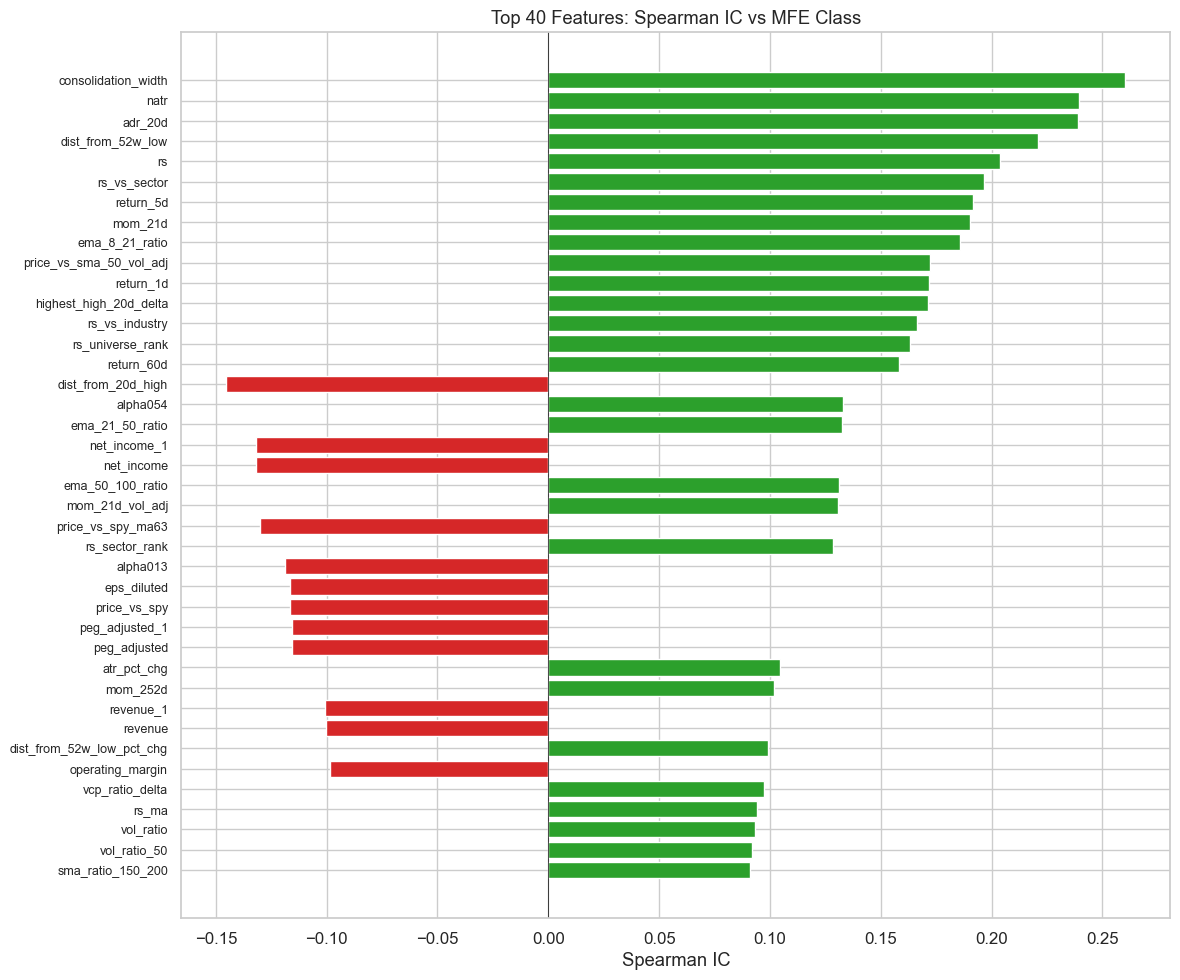

In [24]:
all_features = [f for feats in FEATURE_GROUPS.values() for f in feats if (f in df.columns) and (f not in BANNED_RAW_FEATURES)]
print(f"Total candidate features: {len(all_features)}")

# Spearman rank correlation with target
ic_results = []
for feat in all_features:
    series = df[feat].replace([np.inf, -np.inf], np.nan).dropna()
    if len(series) < 100:
        continue
    aligned_target = df.loc[series.index, 'target_class']
    corr, pval = stats.spearmanr(series, aligned_target)
    ic_results.append({'feature': feat, 'spearman_ic': corr, 'pval': pval, 'abs_ic': abs(corr)})

ic_df = pd.DataFrame(ic_results).sort_values('abs_ic', ascending=False).reset_index(drop=True)

# Top 30 by absolute IC
print("\nTop 30 Features by |Spearman IC| vs target_class:")
print(ic_df.head(30).to_string(index=False))

# Bottom 10
print("\nBottom 10 (lowest IC, least predictive):")
print(ic_df.tail(10).to_string(index=False))

# IC bar chart — top 40
fig, ax = plt.subplots(figsize=(12, 10))
top40 = ic_df.head(40)
colors = ['#2ca02c' if x > 0 else '#d62728' for x in top40['spearman_ic']]
ax.barh(range(len(top40)), top40['spearman_ic'], color=colors)
ax.set_yticks(range(len(top40)))
ax.set_yticklabels(top40['feature'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Spearman IC')
ax.set_title('Top 40 Features: Spearman IC vs MFE Class')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


### Mutual info

C:\Users\Hang\AppData\Local\Temp\ipykernel_23728\2787962504.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_mi['sector'] = le.fit_transform(X_mi['sector'].astype(str))
C:\Users\Hang\AppData\Local\Temp\ipykernel_23728\2787962504.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_mi['industry'] = le.fit_transform(X_mi['industry'].astype(str))


Calculating Mutual Information... (this may take a few seconds)

Top 30 Features by Mutual Information:
                  feature  mi_score
           m03_regime_vol  0.075540
                 alpha001  0.071134
         m03_pillar_trend  0.069593
           m03_pillar_liq  0.063932
          m03_pillar_risk  0.057720
          sector_momentum  0.037278
       dist_from_20d_high  0.036633
                     natr  0.032700
      consolidation_width  0.031402
   highest_high_20d_delta  0.028632
                m03_score  0.028036
         rs_universe_rank  0.026979
                  adr_20d  0.024679
            m03_delta_20d  0.024589
                 alpha054  0.024154
             m03_delta_5d  0.021785
             rs_vs_sector  0.021245
        dist_from_52w_low  0.019170
                  mom_21d  0.018544
                       rs  0.017887
              atr_pct_chg  0.017413
           rs_vs_industry  0.016519
               return_60d  0.016393
                      roa  0.016

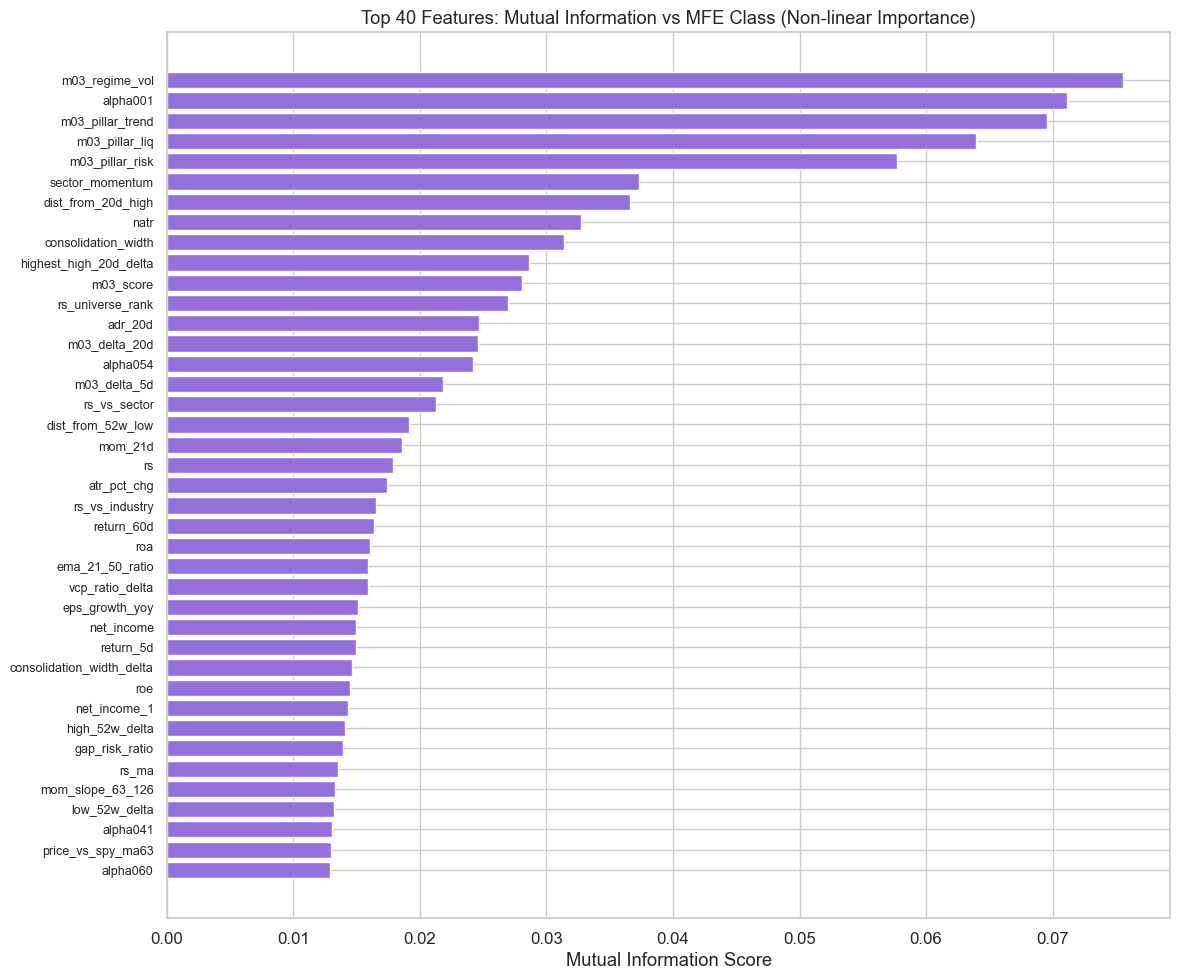

In [25]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# 1. Prepare data (MI cannot handle NaNs or Infs mathematically)
# We sample 20,000 rows to make this computation lightning-fast for EDA. 
mi_data = df.replace([np.inf, -np.inf], np.nan).dropna(subset=all_features + ['target_class'])

mi_sample = mi_data.sample(n=min(20000, len(mi_data)), random_state=42)

X_mi = mi_sample[all_features]
y_mi = mi_sample['target_class']

le = LabelEncoder()
if 'sector' in X_mi.columns:
    X_mi['sector'] = le.fit_transform(X_mi['sector'].astype(str))
if 'industry' in X_mi.columns:
    X_mi['industry'] = le.fit_transform(X_mi['industry'].astype(str))

# 2. Calculate Mutual Information
# discrete_features=False assumes your financial features are continuous (floats)
print("Calculating Mutual Information... (this may take a few seconds)")
mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features=False, random_state=42)

# 3. Store in a DataFrame and sort
mi_results = pd.DataFrame({
    'feature': all_features,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

print("\nTop 30 Features by Mutual Information:")
print(mi_results.head(30).to_string(index=False))

# 4. Bar chart — top 40 non-linear drivers
fig, ax = plt.subplots(figsize=(12, 10))
top40_mi = mi_results.head(40)

# MI is always positive, so we just use one color
ax.barh(range(len(top40_mi)), top40_mi['mi_score'], color='mediumpurple')
ax.set_yticks(range(len(top40_mi)))
ax.set_yticklabels(top40_mi['feature'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 40 Features: Mutual Information vs MFE Class (Non-linear Importance)')

plt.tight_layout()
plt.show()


### Multicollinearity

Findings
- EMA Dominance: Spearman IC favors highly correlated trend features (EMAs/SMAs). Keeping all of them dilutes feature importance and adds redundant noise to XGBoost.
- Value of Non-Linearity: Features with low IC but high Mutual Information (alpha001, m03_*) capture complex, non-linear relationships (e.g., thresholds, U-shapes). These are goldmines for XGBoost.
- Severe Multicollinearity: The heatmap confirms overlapping lookback periods (momentum, returns, MAs) are highly clustered, meaning we are feeding the model the same information multiple times.

To-Do List
- [ ] Convert to Ratios/Z-scores: Swap raw price_vs_EMA features for Moving Average Ratios (e.g., ema_21 / ema_50) or volatility-normalized distances, then drop the raw constituents.
- [ ] Prune Timeframes: Force a bucketed approach. Pick exactly one short (e.g., 21d), one medium (e.g., 50d), and one long (e.g., 200d) lookback. Drop intermediate overlap.
- [ ] Retain High-MI Features: Ensure alpha001 and m03_* features are kept in the final feature set, regardless of their Spearman rank.
- [ ] Run Hierarchical Clustering: Group features based on their Spearman correlation (cutting the threshold around highly correlated ~0.75+).
- [ ] Apply "MI Tiebreaking": For every correlation cluster identified, select the single feature with the highest Mutual Information score. Delete the rest.

Analyzing Multicollinearity for 74 unique top predictors...



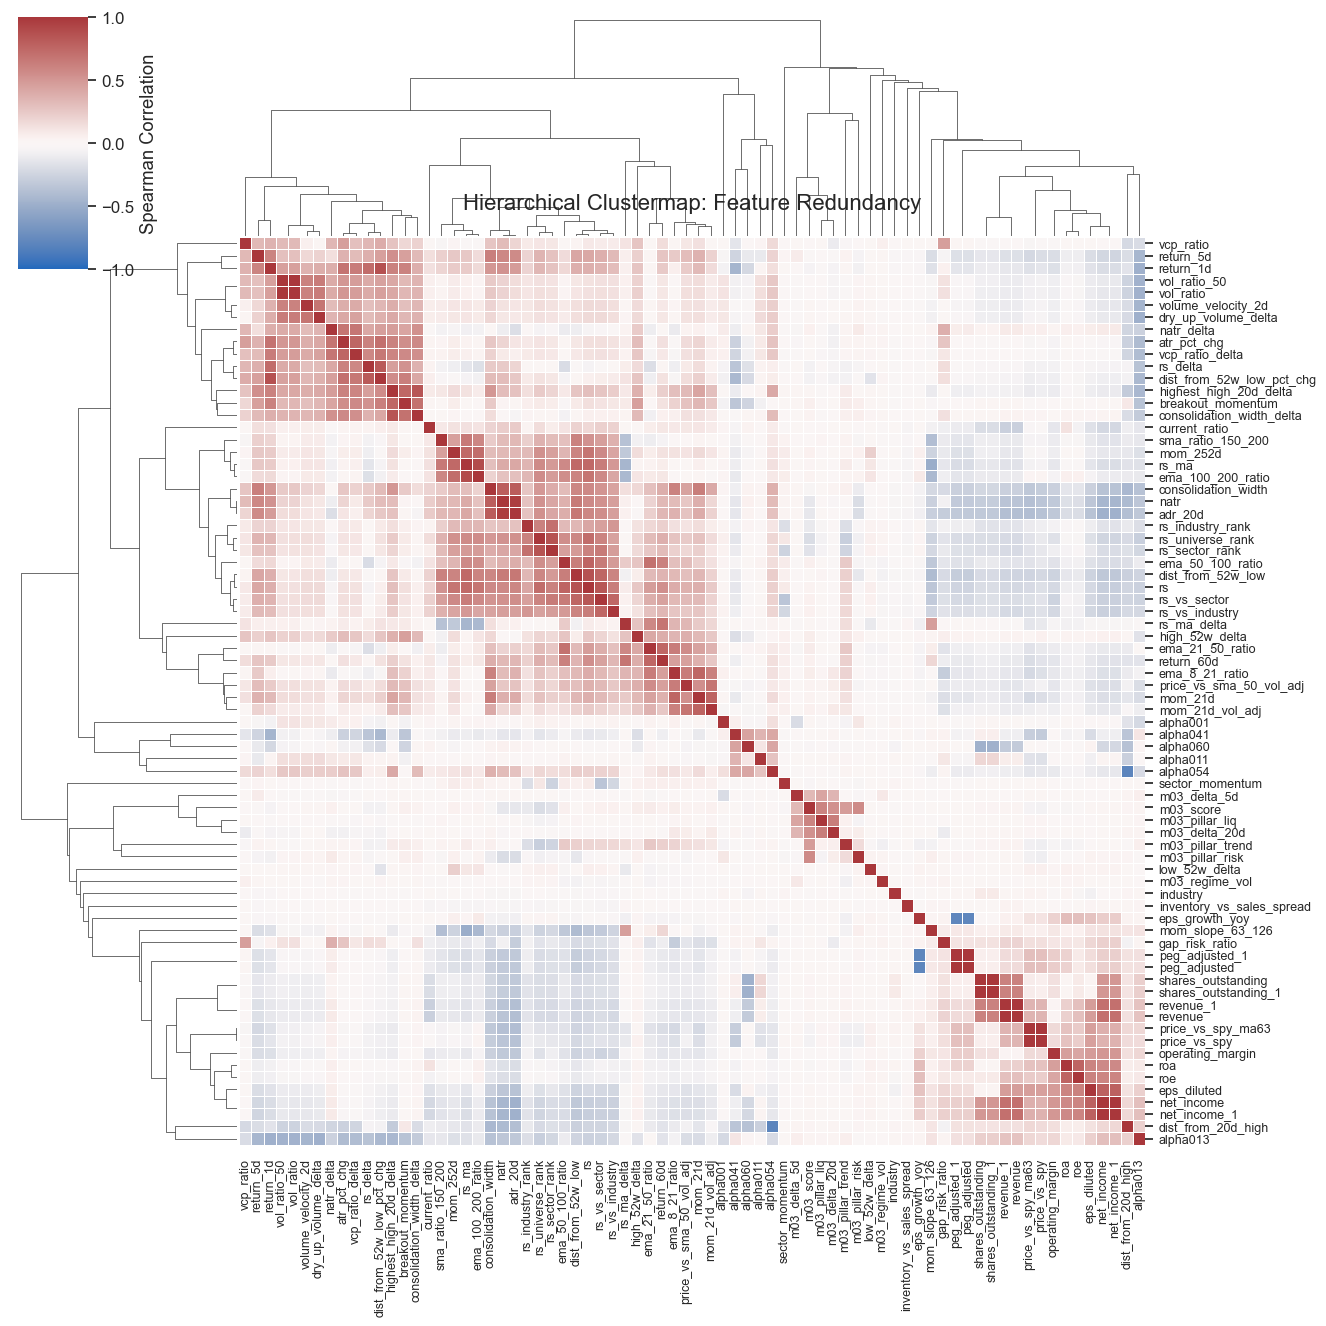


Highly Correlated Pairs (|r| > 0.8):
                    Feature_A                  Feature_B  Correlation
0          shares_outstanding       shares_outstanding_1     1.000000
1                   revenue_1                    revenue     0.999995
2                  net_income               net_income_1     0.999642
3              peg_adjusted_1               peg_adjusted     0.999580
4           price_vs_spy_ma63               price_vs_spy     0.997249
5                vol_ratio_50                  vol_ratio     0.996075
6                        natr                    adr_20d     0.968252
7                       rs_ma          ema_100_200_ratio     0.895768
8   dist_from_52w_low_pct_chg                  return_1d     0.874170
9           dist_from_52w_low                         rs     0.864704
10           rs_universe_rank             rs_sector_rank     0.858256
11     highest_high_20d_delta  consolidation_width_delta     0.845652
12               rs_vs_sector                       

In [26]:
# 1. Combine top features from both linear (IC) and non-linear (MI) lists
top_ic_feats = ic_df.head(50)['feature'].tolist()
# Assuming mi_results from your previous cell is stored in memory
top_mi_feats = mi_results.head(50)['feature'].tolist()

# Get unique features (this removes duplicates if a feature scored high on both)
combined_top_features = list(set(top_ic_feats + top_mi_feats))
print(f"Analyzing Multicollinearity for {len(combined_top_features)} unique top predictors...\n")

le = LabelEncoder()
if 'sector' in df.columns:
    df['sector'] = le.fit_transform(df['sector'].astype(str))
if 'industry' in df.columns:
    df['industry'] = le.fit_transform(df['industry'].astype(str))

# 2. Compute Spearman Correlation Matrix
corr_matrix = df[combined_top_features].replace([np.inf, -np.inf], np.nan).corr(method='spearman')

# 3. Industry Standard Plot: Hierarchical Clustermap
# This algorithm groups redundant features together into visual "blocks"
g = sns.clustermap(
    corr_matrix, 
    method='average',      # Clustering linkage method
    metric='correlation',  # Distance metric
    cmap='vlag',           # Clean diverging colormap (blue to red)
    center=0, vmin=-1, vmax=1,
    figsize=(14, 14), 
    linewidths=0.5, 
    annot=False,
    cbar_kws={"shrink": .5, "label": "Spearman Correlation"},
    xticklabels=corr_matrix.columns,
    yticklabels=corr_matrix.index
)

# Formatting the Clustermap
g.ax_heatmap.set_title('Hierarchical Clustermap: Feature Redundancy', pad=20, fontsize=16)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=9)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)
plt.show()

# 4. Clean, Pythonic way to find Highly Correlated Pairs (|r| > 0.85)
HIGH_CORR_THRESHOLD = 0.80

# Mask out the bottom triangle and diagonal to avoid counting A->B and B->A twice
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Stack the dataframe, reset index, and filter purely in pandas
pairs_df = upper_tri.stack().reset_index()
pairs_df.columns = ['Feature_A', 'Feature_B', 'Correlation']

# Filter and sort
highly_correlated = pairs_df[pairs_df['Correlation'].abs() > HIGH_CORR_THRESHOLD].copy()
highly_correlated['Abs_Corr'] = highly_correlated['Correlation'].abs()
highly_correlated = highly_correlated.sort_values(by='Abs_Corr', ascending=False).drop(columns=['Abs_Corr']).reset_index(drop=True)

print(f"\nHighly Correlated Pairs (|r| > {HIGH_CORR_THRESHOLD}):")
print(highly_correlated.to_string())
print(f"\nTotal highly correlated pairs: {len(highly_correlated)}")


## Feature Selection

In [27]:
IC_THRESHOLD = 0.02
# Expand to Top 50 MI to capture good non-linear features
top_mi_features = mi_results.head(50)['feature'].tolist()
survivors = set()
for _, row in ic_df.iterrows():
    feat = row['feature']
    if feat in BANNED_RAW_FEATURES:
        continue
    
    # Needs strong IC -OR- be in the Top 50 MI
    if row['abs_ic'] >= IC_THRESHOLD or feat in top_mi_features:
        survivors.add(feat)
survivors_list = list(survivors)
print(f"Features passing base signal test: {len(survivors_list)}")

print("Computing pairwise correlation for ALL survivors...")
# Note: select_dtypes prevents categorical columns from crashing the matrix
corr_matrix_survivors = df[survivors_list].select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).corr(method='spearman')
# Extract pairs
survivor_pairs = []
for i in range(len(corr_matrix_survivors.columns)):
    for j in range(i):
        a = corr_matrix_survivors.columns[i]
        b = corr_matrix_survivors.columns[j]
        # Ignore target variable leakage just in case
        if a == 'target_class' or b == 'target_class': continue
            
        corr_val = abs(corr_matrix_survivors.iloc[i, j])
        if corr_val > 0.8:
            survivor_pairs.append({'Feature_A': a, 'Feature_B': b, 'Correlation': corr_val})
highly_corr_df = pd.DataFrame(survivor_pairs)
print(f"Found {len(highly_corr_df)} highly correlated pairs within the survivors to prune.")


Features passing base signal test: 112
Computing pairwise correlation for ALL survivors...
Found 21 highly correlated pairs within the survivors to prune.


In [28]:
highly_corr_df.sort_values('Correlation', ascending=0)

,Feature_A,Feature_B,Correlation
20,shares_outstanding_1,shares_outstanding,1.000000
5,revenue,revenue_1,0.999995
3,net_income,net_income_1,0.999642
8,peg_adjusted_1,peg_adjusted,0.999580
4,price_vs_spy,price_vs_spy_ma63,0.997249
11,vol_ratio,vol_ratio_50,0.996075
12,turnover,turnover_ma20,0.968640
14,natr,adr_20d,0.968252
2,alpha049,alpha051,0.957012
6,current_ratio,quick_ratio,0.941364


In [29]:
DOMAIN_KEEP_PAIRS = [
    {'rs_sector_rank', 'rs_universe_rank'}, # Sector rotation orthogonal variance
    {'rs_vs_sector', 'rs'},
    {'natr', 'adr_20d'}, # Gap Volatility divergence
    {'adr_20d', 'consolidation_width'}, # Intraday vs Multi-day box logic
    {'consolidation_width_delta', 'highest_high_20d_delta'} # Peak break vs window timeout logic
]

In [30]:
# Create dictionaries to lookup rank instantly (1 = best)
ic_rank = {feat: rank for rank, feat in enumerate(ic_df['feature'], 1)}
mi_rank = {feat: rank for rank, feat in enumerate(mi_results['feature'], 1)}
def get_combined_rank(feat):
    # If a feature passed IC but isn't in top MI (or vice-versa), penalize it in tie-breakers
    return ic_rank.get(feat, 200) + mi_rank.get(feat, 200)
to_drop = set()
if not highly_corr_df.empty:
    for _, row in highly_corr_df.iterrows():
        a, b = row['Feature_A'], row['Feature_B']
        
        # Check if this pair is immune to mathematical pruning
        pair_set = {a, b}
        is_immune = any(pair_set.issubset(immune_pair) for immune_pair in DOMAIN_KEEP_PAIRS)
        
        if is_immune:
             continue # Keep both!
            
        # Standard pruning: Drop the mathematically weaker feature
        if get_combined_rank(a) <= get_combined_rank(b):
            to_drop.add(b)
        else:
            to_drop.add(a)
selected_features = [f for f in survivors_list if f not in to_drop]
print(f"Pruned {len(to_drop)} redundant features. Saved {len(DOMAIN_KEEP_PAIRS)} domain pairs.")


Pruned 14 redundant features. Saved 5 domain pairs.


In [31]:
CATEGORICAL_FEATURES = []
for cat in ['sector', 'industry']:
    if cat in df.columns and df[cat].nunique() > 1:
        df[cat] = df[cat].astype('category')
        CATEGORICAL_FEATURES.append(cat)
        if cat not in selected_features:
            selected_features.append(cat)
print(f"\nFinal feature set: {len(selected_features)} features")
print(f"  Categorical: {CATEGORICAL_FEATURES}")
print(f"  Numeric: {len(selected_features) - len(CATEGORICAL_FEATURES)}")


Final feature set: 99 features
  Categorical: ['sector', 'industry']
  Numeric: 97


In [32]:
# check scope change
prod_feature_set_set = set([f.lower() for f in prod_feature_set['feature_name'].values])
selected_features_set = set(selected_features)

new_feat_added = selected_features_set - prod_feature_set_set
feat_removed = prod_feature_set_set - selected_features_set

print(f"Removed from Prod ({len(feat_removed)} features):")
print(sorted(list(feat_removed)))

print(f"\nNewly added ({len(new_feat_added)} features):")
print(sorted(list(new_feat_added)))

Removed from Prod (32 features):
['alpha002', 'alpha101', 'atr_delta', 'breakout', 'close_above_sma200', 'consolidation_duration', 'days_since_report', 'dist_from_20d_low', 'dist_from_20d_low_delta', 'dist_from_52w_high', 'dist_from_52w_low_delta', 'dry_up_volume', 'eps_accel', 'green_days_ratio_20d', 'is_green_day', 'lowest_low_20d_delta', 'mom_126d', 'mom_189d', 'mom_63d', 'net_income_growth_yoy', 'price_vs_sma_150', 'price_vs_sma_150_delta', 'price_vs_sma_200', 'price_vs_sma_200_delta', 'price_vs_sma_50', 'price_vs_sma_50_delta', 'ps_ratio', 'rs', 'rs_line_delta', 'rs_line_uptrend', 'rs_rating', 'rs_velocity']

Newly added (25 features):
['adr_20d', 'alpha008', 'atr_pct_chg', 'dollar_volume_avg_20', 'ema_21_50_ratio', 'ema_50_100_ratio', 'ema_8_21_ratio', 'gap_risk_ratio', 'industry', 'inventory_vs_sales_spread', 'mom_21d_vol_adj', 'mom_slope_21_63', 'mom_slope_63_126', 'net_income', 'peg_adjusted_1', 'price_vs_sma_50_vol_adj', 'price_vs_spy_ma63', 'return_60d', 'revenue', 'rs_unive

## (Optional) Replace with prod feature

In [33]:
### Replace selected features with prod feature set
# selected_features = list(prod_feature_set_set)
# df['atr_delta'] = df['atr_pct_chg']

## Model

### Walk-Forward Validation Setup

In [34]:
import xgboost as xgb
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

df['year'] = df['date'].dt.year
years = sorted(df['year'].unique())
print(f"Available years: {years}")

TRAIN_WINDOW = 3  # years
TEST_WINDOW = 1   # year

folds = []
for i in range(len(years) - TRAIN_WINDOW):
    train_years = years[i:i + TRAIN_WINDOW]
    test_year = years[i + TRAIN_WINDOW]
    if test_year > years[-1]:
        break
    folds.append({'train_years': train_years, 'test_year': test_year})

print(f"\nWalk-Forward Folds ({len(folds)}):")
for fold in folds:
    train_n = df[df['year'].isin(fold['train_years'])].shape[0]
    test_n = df[df['year'] == fold['test_year']].shape[0]
    print(f"  Train {fold['train_years']} ({train_n:,}) -> Test [{fold['test_year']}] ({test_n:,})")


Available years: [np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]

Walk-Forward Folds (21):
  Train [np.int32(2003), np.int32(2004), np.int32(2005)] (2,871) -> Test [2006] (1,036)
  Train [np.int32(2004), np.int32(2005), np.int32(2006)] (3,217) -> Test [2007] (1,255)
  Train [np.int32(2005), np.int32(2006), np.int32(2007)] (3,341) -> Test [2008] (451)
  Train [np.int32(2006), np.int32(2007), np.int32(2008)] (2,742) -> Test [2009] (864)
  Train [np.int32(2007), np.int32(2008), np.int32(2009)] (2,570) -> Test [2010] (1,488)
  Train [np.int32(2008), np.int32(2009), np.int32(2010)] (2,803) -> Test [2011] (1,278)
  Train [np.int32(2009), np.int32(2010), np.int3

In [126]:
import xgboost as xgb
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

df['year'] = df['date'].dt.year
years = sorted(df['year'].unique())
print(f"Available years: {years}")

INITIAL_TRAIN_WINDOW = 3  # Minimum years needed to train the first fold
# TEST_WINDOW is inherently 1 in this loop

folds = []
# Start the loop at the index where we have enough initial training data
for i in range(INITIAL_TRAIN_WINDOW, len(years)):
    # EXPANDING WINDOW: Always start at index 0, expand up to 'i'
    train_years = years[0:i] 
    test_year = years[i]
    
    folds.append({'train_years': train_years, 'test_year': test_year})

print(f"\nWalk-Forward Folds (Expanding Window) ({len(folds)}):")
for fold in folds:
    train_n = df[df['year'].isin(fold['train_years'])].shape[0]
    test_n = df[df['year'] == fold['test_year']].shape[0]
    print(f"  Train {fold['train_years'][0]}-{fold['train_years'][-1]} ({train_n:,}) -> Test [{fold['test_year']}] ({test_n:,})")


Available years: [np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]

Walk-Forward Folds (Expanding Window) (21):
  Train 2003-2005 (2,871) -> Test [2006] (1,036)
  Train 2003-2006 (3,907) -> Test [2007] (1,255)
  Train 2003-2007 (5,162) -> Test [2008] (451)
  Train 2003-2008 (5,613) -> Test [2009] (864)
  Train 2003-2009 (6,477) -> Test [2010] (1,488)
  Train 2003-2010 (7,965) -> Test [2011] (1,278)
  Train 2003-2011 (9,243) -> Test [2012] (1,292)
  Train 2003-2012 (10,535) -> Test [2013] (2,136)
  Train 2003-2013 (12,671) -> Test [2014] (1,508)
  Train 2003-2014 (14,179) -> Test [2015] (1,341)
  Train 2003-2015 (15,520) -> Test [2016] (1,636)
  Train 2003-2

### Model Training: Walk-Forward XGBoost

In [127]:
XGB_PARAMS = {
    'objective': 'multi:softprob',
    'num_class': 4,
    'max_depth': 4,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'enable_categorical': True,
    'random_state': 42,
    'verbosity': 0
}
NUM_BOOST_ROUND = 300
EARLY_STOPPING = 30

numeric_features = [f for f in selected_features if f not in CATEGORICAL_FEATURES]

fold_results = []
fold_models = []
all_test_preds = []

for fold_idx, fold in enumerate(folds):
    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx + 1}: Train {fold['train_years']} -> Test [{fold['test_year']}]")
    print(f"{'='*60}")

    train_mask = df['year'].isin(fold['train_years'])
    test_mask = df['year'] == fold['test_year']

    X_train = df.loc[train_mask, selected_features].copy()
    y_train = df.loc[train_mask, 'target_class'].values
    X_test = df.loc[test_mask, selected_features].copy()
    y_test = df.loc[test_mask, 'target_class'].values

    # Clean inf values (numeric only)
    X_train[numeric_features] = X_train[numeric_features].replace([np.inf, -np.inf], np.nan)
    X_test[numeric_features] = X_test[numeric_features].replace([np.inf, -np.inf], np.nan)

    # Class weights
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    weight_map = dict(zip(classes, weights))
    sample_weights = np.array([weight_map.get(y, 1.0) for y in y_train])

    # DMatrix
    dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weights, enable_categorical=True)
    dtest = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)

    # Train with early stopping (use 20% of train as eval)
    eval_split = int(len(X_train) * 0.8)
    dtrain_fit = xgb.DMatrix(
        X_train.iloc[:eval_split], label=y_train[:eval_split],
        weight=sample_weights[:eval_split], enable_categorical=True
    )
    deval = xgb.DMatrix(
        X_train.iloc[eval_split:], label=y_train[eval_split:], enable_categorical=True
    )

    model = xgb.train(
        params=XGB_PARAMS,
        dtrain=dtrain_fit,
        num_boost_round=NUM_BOOST_ROUND,
        evals=[(dtrain_fit, 'train'), (deval, 'eval')],
        early_stopping_rounds=EARLY_STOPPING,
        verbose_eval=False
    )

    # Predict
    y_pred_proba = model.predict(dtest)
    y_pred = np.argmax(y_pred_proba, axis=1)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    w_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    m_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    per_class_f1 = f1_score(y_test, y_pred, average=None, zero_division=0)

    fold_result = {
        'fold': fold_idx + 1,
        'test_year': fold['test_year'],
        'n_train': len(X_train),
        'n_test': len(X_test),
        'best_iteration': model.best_iteration,
        'accuracy': acc,
        'weighted_f1': w_f1,
        'macro_f1': m_f1
    }
    for cls_idx, cls_name in CLASS_NAMES.items():
        if cls_idx < len(per_class_f1):
            fold_result[f'f1_class_{cls_idx}'] = per_class_f1[cls_idx]
    fold_results.append(fold_result)
    fold_models.append(model)

    # Store predictions for aggregate analysis
    test_df = df.loc[test_mask, ['ticker', 'date', 'mfe_pct', 'target_class']].copy()
    test_df['y_pred'] = y_pred
    test_df['fold'] = fold_idx + 1
    for c in range(4):
        test_df[f'prob_class_{c}'] = y_pred_proba[:, c]
    all_test_preds.append(test_df)

    print(f"  Acc={acc:.3f} | W-F1={w_f1:.3f} | M-F1={m_f1:.3f} | best_iter={model.best_iteration}")
    print(f"  Per-class F1: {[f'{x:.3f}' for x in per_class_f1]}")

results_df = pd.DataFrame(fold_results)
preds_df = pd.concat(all_test_preds, ignore_index=True)

print("\n" + "=" * 60)
print("WALK-FORWARD SUMMARY")
print("=" * 60)
print(results_df.to_string(index=False))
print(f"\nMean Accuracy:    {results_df['accuracy'].mean():.3f} +/- {results_df['accuracy'].std():.3f}")
print(f"Mean Weighted F1: {results_df['weighted_f1'].mean():.3f} +/- {results_df['weighted_f1'].std():.3f}")
print(f"Mean Macro F1:    {results_df['macro_f1'].mean():.3f} +/- {results_df['macro_f1'].std():.3f}")




FOLD 1: Train [np.int32(2003), np.int32(2004), np.int32(2005)] -> Test [2006]
  Acc=0.328 | W-F1=0.327 | M-F1=0.279 | best_iter=54
  Per-class F1: ['0.296', '0.462', '0.220', '0.140']

FOLD 2: Train [np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006)] -> Test [2007]
  Acc=0.346 | W-F1=0.353 | M-F1=0.298 | best_iter=96
  Per-class F1: ['0.313', '0.463', '0.248', '0.169']

FOLD 3: Train [np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007)] -> Test [2008]
  Acc=0.359 | W-F1=0.371 | M-F1=0.326 | best_iter=176
  Per-class F1: ['0.319', '0.444', '0.337', '0.204']

FOLD 4: Train [np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008)] -> Test [2009]
  Acc=0.331 | W-F1=0.344 | M-F1=0.295 | best_iter=139
  Per-class F1: ['0.261', '0.411', '0.333', '0.173']

FOLD 5: Train [np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009)] -> Test [2010]
  Acc=0.327 | W-F1=

### Walk-Forward Stability Plot

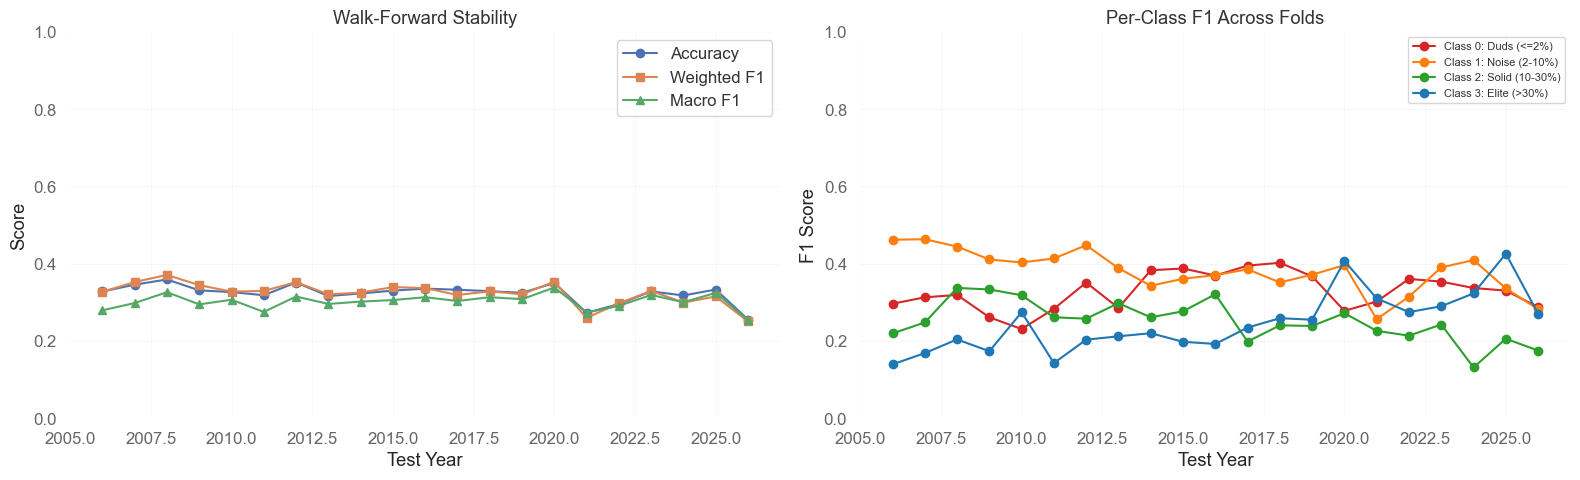

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 12a. Metrics across folds
axes[0].plot(results_df['test_year'], results_df['accuracy'], 'o-', label='Accuracy')
axes[0].plot(results_df['test_year'], results_df['weighted_f1'], 's-', label='Weighted F1')
axes[0].plot(results_df['test_year'], results_df['macro_f1'], '^-', label='Macro F1')
axes[0].set_xlabel('Test Year')
axes[0].set_ylabel('Score')
axes[0].set_title('Walk-Forward Stability')
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

# 12b. Per-class F1 across folds
for cls_idx in sorted(CLASS_NAMES.keys()):
    col = f'f1_class_{cls_idx}'
    if col in results_df.columns:
        axes[1].plot(results_df['test_year'], results_df[col], 'o-',
                     label=CLASS_NAMES[cls_idx], color=CLASS_COLORS[cls_idx])
axes[1].set_xlabel('Test Year')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Per-Class F1 Across Folds')
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Aggregate Confusion Matrix (all OOS folds)

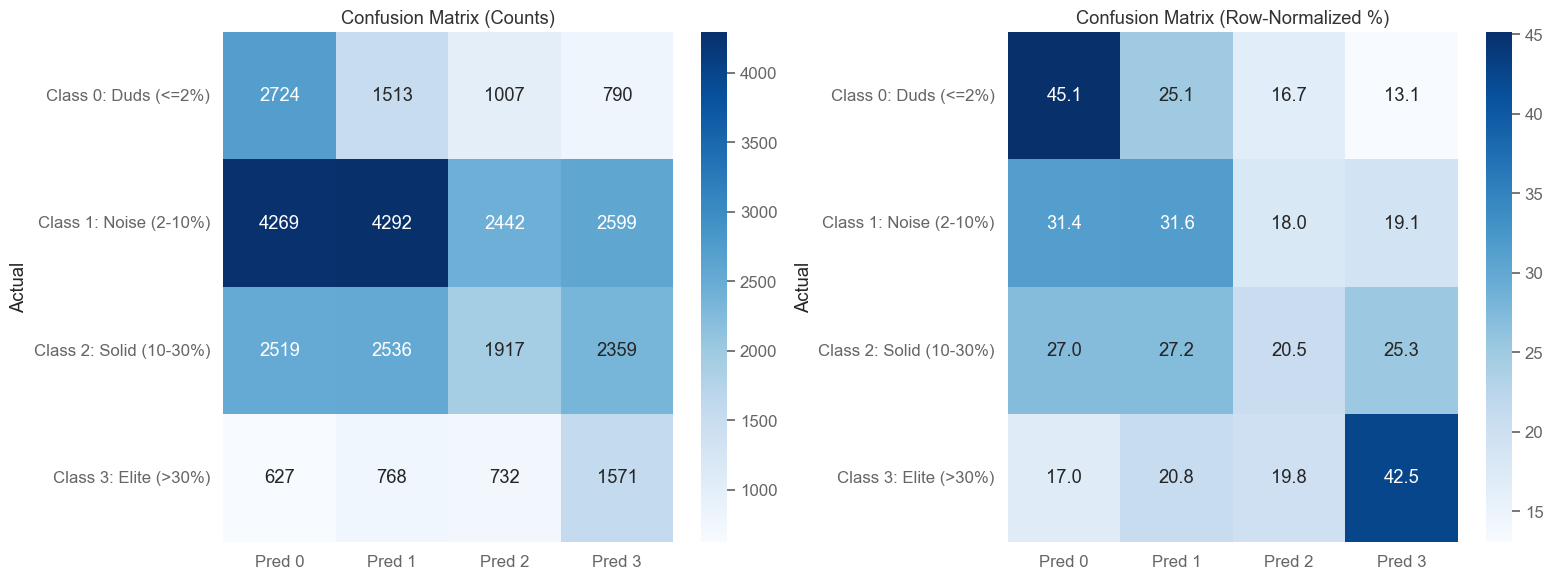


Aggregate OOS Classification Report:
                         precision    recall  f1-score   support

   Class 0: Duds (<=2%)       0.27      0.45      0.34      6034
 Class 1: Noise (2-10%)       0.47      0.32      0.38     13602
Class 2: Solid (10-30%)       0.31      0.21      0.25      9331
  Class 3: Elite (>30%)       0.21      0.42      0.29      3698

               accuracy                           0.32     32665
              macro avg       0.32      0.35      0.31     32665
           weighted avg       0.36      0.32      0.32     32665



In [129]:
cm = confusion_matrix(preds_df['target_class'], preds_df['y_pred'])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f'Pred {c}' for c in CLASS_NAMES.keys()],
            yticklabels=[CLASS_NAMES[c] for c in CLASS_NAMES.keys()])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_ylabel('Actual')

# Normalized (%)
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=[f'Pred {c}' for c in CLASS_NAMES.keys()],
            yticklabels=[CLASS_NAMES[c] for c in CLASS_NAMES.keys()])
axes[1].set_title('Confusion Matrix (Row-Normalized %)')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Per-class precision/recall from aggregate predictions
print("\nAggregate OOS Classification Report:")
print(classification_report(
    preds_df['target_class'], preds_df['y_pred'],
    target_names=[CLASS_NAMES[c] for c in sorted(CLASS_NAMES.keys())],
    zero_division=0
))


## (Optional) Train Prod Model

In [96]:
# 1. Filter out anything from 2025 onwards
# train_df = df[df['date'] < '2025-01-01'].sort_values('date').copy()
train_df = df.copy()

# 2. Get X and y
X_all = train_df[selected_features].copy()
y_all = train_df['target_class'].values

# Clean inf values on numeric features only
X_all[numeric_features] = X_all[numeric_features].replace([np.inf, -np.inf], np.nan)

# Explicitly cast categorical columns for XGBoost tree_method='hist'
for col in CATEGORICAL_FEATURES:
    if col in X_all.columns:
        X_all[col] = X_all[col].astype('category')

# 3. Recompute class weights
classes = np.unique(y_all)
weights = compute_class_weight('balanced', classes=classes, y=y_all)
weight_map = dict(zip(classes, weights))
sample_weights = np.array([weight_map.get(y, 1.0) for y in y_all])

# 4. Create temporal split for Early Stopping (using the final 20% of rows as the eval set)
eval_split = int(len(X_all) * 0.8)

dtrain_fit = xgb.DMatrix(
    X_all.iloc[:eval_split], 
    label=y_all[:eval_split],
    weight=sample_weights[:eval_split], 
    enable_categorical=True
)
deval = xgb.DMatrix(
    X_all.iloc[eval_split:], 
    label=y_all[eval_split:], 
    enable_categorical=True
)

# 5. Train the model
print(f"Training on {eval_split:,} rows, Evaluating on {len(X_all)-eval_split:,} rows...")
model = xgb.train(
    params=XGB_PARAMS,
    dtrain=dtrain_fit,
    num_boost_round=NUM_BOOST_ROUND,
    evals=[(dtrain_fit, 'train'), (deval, 'eval')],
    early_stopping_rounds=EARLY_STOPPING,
    verbose_eval=50
)

Training on 28,428 rows, Evaluating on 7,108 rows...
[0]	train-mlogloss:1.37882	eval-mlogloss:1.38230
[50]	train-mlogloss:1.22865	eval-mlogloss:1.31000
[100]	train-mlogloss:1.17665	eval-mlogloss:1.29318
[150]	train-mlogloss:1.13900	eval-mlogloss:1.28510
[200]	train-mlogloss:1.10508	eval-mlogloss:1.28014
[250]	train-mlogloss:1.07411	eval-mlogloss:1.27677
[299]	train-mlogloss:1.04539	eval-mlogloss:1.27274


#### (Optional) Compare Cached Model

In [97]:
import xgboost as xgb
import json
import numpy as np
# Assuming ROOT is already defined as your project root path

# 1. Paths
MODEL = 'm01_baseline_full'
model_dir = ROOT / 'models' / MODEL
model_path  = str(model_dir / 'model.json')
metadata_path = str(model_dir / 'metadata.json')

# 2. Load the cached model
cached_model = xgb.Booster()
cached_model.load_model(model_path)

# 3. Load the exact features the model was trained on
with open(metadata_path, 'r') as f:
    meta = json.load(f)
    cached_features = meta['valid_features']

print(f"Loaded model expecting {len(cached_features)} features.")

# 4. Prepare X_test using the cached features strictly
X_test_cached = test_df[cached_features].copy()

# Clean inf values on numeric features only (ensure numeric_features is defined)
X_test_cached[numeric_features] = X_test_cached[numeric_features].replace([np.inf, -np.inf], np.nan)

# Explicitly cast categorical columns for XGBoost tree_method='hist'
for col in CATEGORICAL_FEATURES:
    if col in X_test_cached.columns:
        X_test_cached[col] = X_test_cached[col].astype('category')

# 5. Predict using the cached model
dtest = xgb.DMatrix(X_test_cached, label=y_test, enable_categorical=True)
y_pred_proba = cached_model.predict(dtest)
y_pred = np.argmax(y_pred_proba, axis=1)

# You can then run your metrics (accuracy, f1) on this y_pred
model = cached_model

Loaded model expecting 106 features.


KeyError: "['atr_delta'] not in index"

In [98]:
import pandas as pd
import json

# 1. Compare Feature Sets
with open(metadata_path, 'r') as f:
    meta = json.load(f)
    # The JSON you showed has both 'valid_features' and 'features'. 
    # Usually 'features' is the final list used for training.
    cached_features_list = meta.get('features', meta.get('valid_features'))
    cached_features = set(cached_features_list)

retrained_features = set(selected_features)

dropped_features = cached_features - retrained_features
new_features = retrained_features - cached_features

print("=== FEATURE SET DIFFERENCES ===")
print(f"Total Cached Features: {len(cached_features)}")
print(f"Total Retrained Features: {len(retrained_features)}")
print(f"Features in CACHED but NOT retrained ({len(dropped_features)}): {dropped_features}")
print(f"Features in RETRAINED but NOT cached ({len(new_features)}): {new_features}")

# 2. Check Top Features of Cached Model
print("\n=== CACHED MODEL TOP 10 FEATURES ===")
cached_importance = cached_model.get_score(importance_type='gain')
cached_imp_df = pd.DataFrame(list(cached_importance.items()), columns=['Feature', 'Gain'])
cached_imp_df = cached_imp_df.sort_values('Gain', ascending=False)
display(cached_imp_df.head(10))

# 3. Check Top Features of Retrained Model
print("\n=== RETRAINED MODEL TOP 10 FEATURES ===")
retrained_importance = model.get_score(importance_type='gain') # Assuming 'model' is your retrained Booster
retrained_imp_df = pd.DataFrame(list(retrained_importance.items()), columns=['Feature', 'Gain'])
retrained_imp_df = retrained_imp_df.sort_values('Gain', ascending=False)
display(retrained_imp_df.head(10))


=== FEATURE SET DIFFERENCES ===
Total Cached Features: 106
Total Retrained Features: 99
Features in CACHED but NOT retrained (32): {'price_vs_sma_50_delta', 'price_vs_sma_200', 'dist_from_20d_low_delta', 'alpha002', 'days_since_report', 'breakout', 'mom_126d', 'rs_rating', 'mom_189d', 'dist_from_52w_low_delta', 'dist_from_20d_low', 'consolidation_duration', 'ps_ratio', 'atr_delta', 'price_vs_sma_50', 'rs', 'rs_line_delta', 'price_vs_sma_150', 'is_green_day', 'dist_from_52w_high', 'price_vs_sma_200_delta', 'eps_accel', 'price_vs_sma_150_delta', 'lowest_low_20d_delta', 'rs_velocity', 'mom_63d', 'green_days_ratio_20d', 'net_income_growth_yoy', 'dry_up_volume', 'alpha101', 'close_above_sma200', 'rs_line_uptrend'}
Features in RETRAINED but NOT cached (25): {'atr_pct_chg', 'mom_slope_63_126', 'mom_slope_21_63', 'sector', 'rs_universe_rank', 'ema_21_50_ratio', 'price_vs_spy_ma63', 'gap_risk_ratio', 'peg_adjusted_1', 'volume_velocity_2d', 'ema_8_21_ratio', 'net_income', 'price_vs_sma_50_vol_ad

,Feature,Gain
26,dist_from_20d_high,36.455246
65,consolidation_width,34.920647
42,natr,34.762630
20,dist_from_20d_low,22.727152
1,price_vs_sma_50,20.807831
25,highest_high_20d_delta,20.471218
101,price_vs_sma_200,19.064367
13,dist_from_52w_low,17.834703
47,consolidation_width_delta,10.468241
80,return_1d,9.196320



=== RETRAINED MODEL TOP 10 FEATURES ===


,Feature,Gain
19,adr_20d,59.300053
89,dist_from_20d_high,42.865055
3,consolidation_width,40.642567
76,natr,29.287802
58,highest_high_20d_delta,25.612474
53,dist_from_52w_low,21.011999
38,ema_8_21_ratio,15.494058
12,return_1d,13.731764
33,price_vs_spy_ma63,13.414710
49,industry,13.330659


In [ ]:
print("=== MODEL COMPARISON ===")
# Use .best_iteration if early stopping was used, else num_boosted_rounds
c_trees = getattr(cached_model, 'best_iteration', cached_model.num_boosted_rounds())
r_trees = getattr(model, 'best_iteration', model.num_boosted_rounds())

print(f"Cached Model Trees:    {c_trees}")
print(f"Retrained Model Trees: {r_trees}")


### OOS Performance

In [103]:
# 1. Filter out 2025/2026 data
test_df = df[df['date'] >= '2020-01-01'].copy()

# 2. Get X and y
X_test = test_df[selected_features].copy()
y_test = test_df['target_class'].values

# Clean inf values on numeric features only
X_test[numeric_features] = X_test[numeric_features].replace([np.inf, -np.inf], np.nan)

# Explicitly cast categorical columns
for col in CATEGORICAL_FEATURES:
    if col in X_test.columns:
        X_test[col] = X_test[col].astype('category')

# 3. Create DMatrix and predict
dtest = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)
y_pred_proba = model.predict(dtest)
y_pred = np.argmax(y_pred_proba, axis=1)


In [104]:
# 4. Calculate metrics
acc = accuracy_score(y_test, y_pred)
w_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
m_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
per_class_f1 = f1_score(y_test, y_pred, average=None, zero_division=0)

print(f"OOS Accuracy:    {acc:.3f}")
print(f"OOS Weighted F1: {w_f1:.3f}")
print(f"OOS Macro F1:    {m_f1:.3f}")
print(f"OOS Per-class F1: {[f'{x:.3f}' for x in per_class_f1]}")

prod_result_dict = {
    'accuracy': acc,
    'weighted_f1': w_f1,
    'macro_f1': m_f1
}
for cls_idx, f1_val in enumerate(per_class_f1):
    prod_result_dict[f'f1_class_{cls_idx}'] = f1_val
prod_results_df = pd.DataFrame([prod_result_dict])

# 5. Save predictions DataFrame (for calibration plots or inspection)
preds_df = test_df[['ticker', 'date', 'mfe_pct', 'target_class']].copy()
preds_df['y_pred'] = y_pred
for c in range(4):
    preds_df[f'prob_class_{c}'] = y_pred_proba[:, c]


OOS Accuracy:    0.490
OOS Weighted F1: 0.488
OOS Macro F1:    0.488
OOS Per-class F1: ['0.496', '0.509', '0.449', '0.499']


### Feature Importance

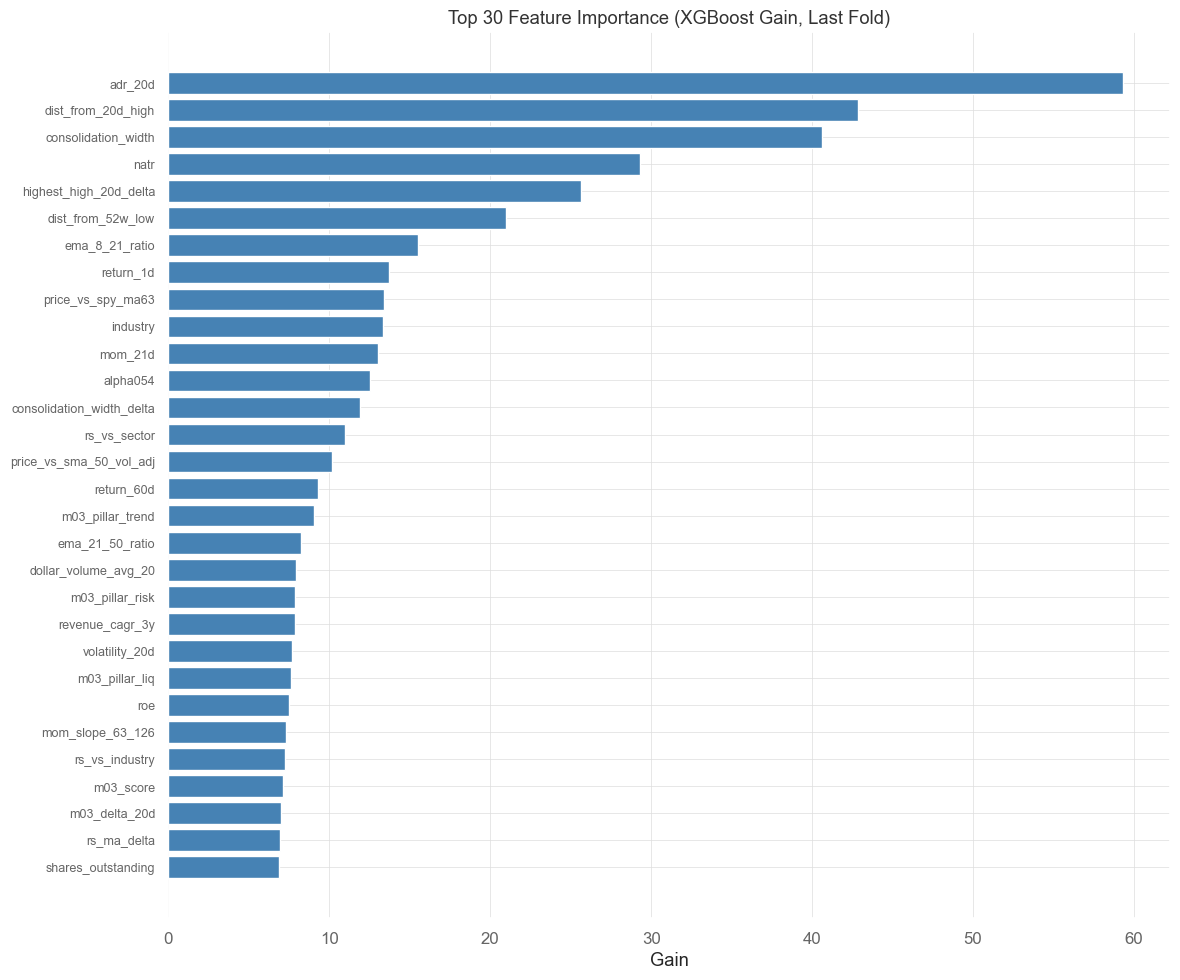

In [105]:
# last_model = fold_models[-1]
importance = model.get_score(importance_type='gain')

# Map feature indices to names
imp_data = []
for feat, gain in importance.items():
    if feat.startswith('f') and feat[1:].isdigit():
        idx = int(feat[1:])
        if idx < len(selected_features):
            imp_data.append({'feature': selected_features[idx], 'gain': gain})
    else:
        imp_data.append({'feature': feat, 'gain': gain})

imp_df = pd.DataFrame(imp_data).sort_values('gain', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 10))
top30 = imp_df.head(30)
ax.barh(range(len(top30)), top30['gain'], color='steelblue')
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30['feature'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Gain')
ax.set_title('Top 30 Feature Importance (XGBoost Gain, Last Fold)')
plt.tight_layout()
plt.show()


### Calibration: Predicted Probability vs Actual Outcome

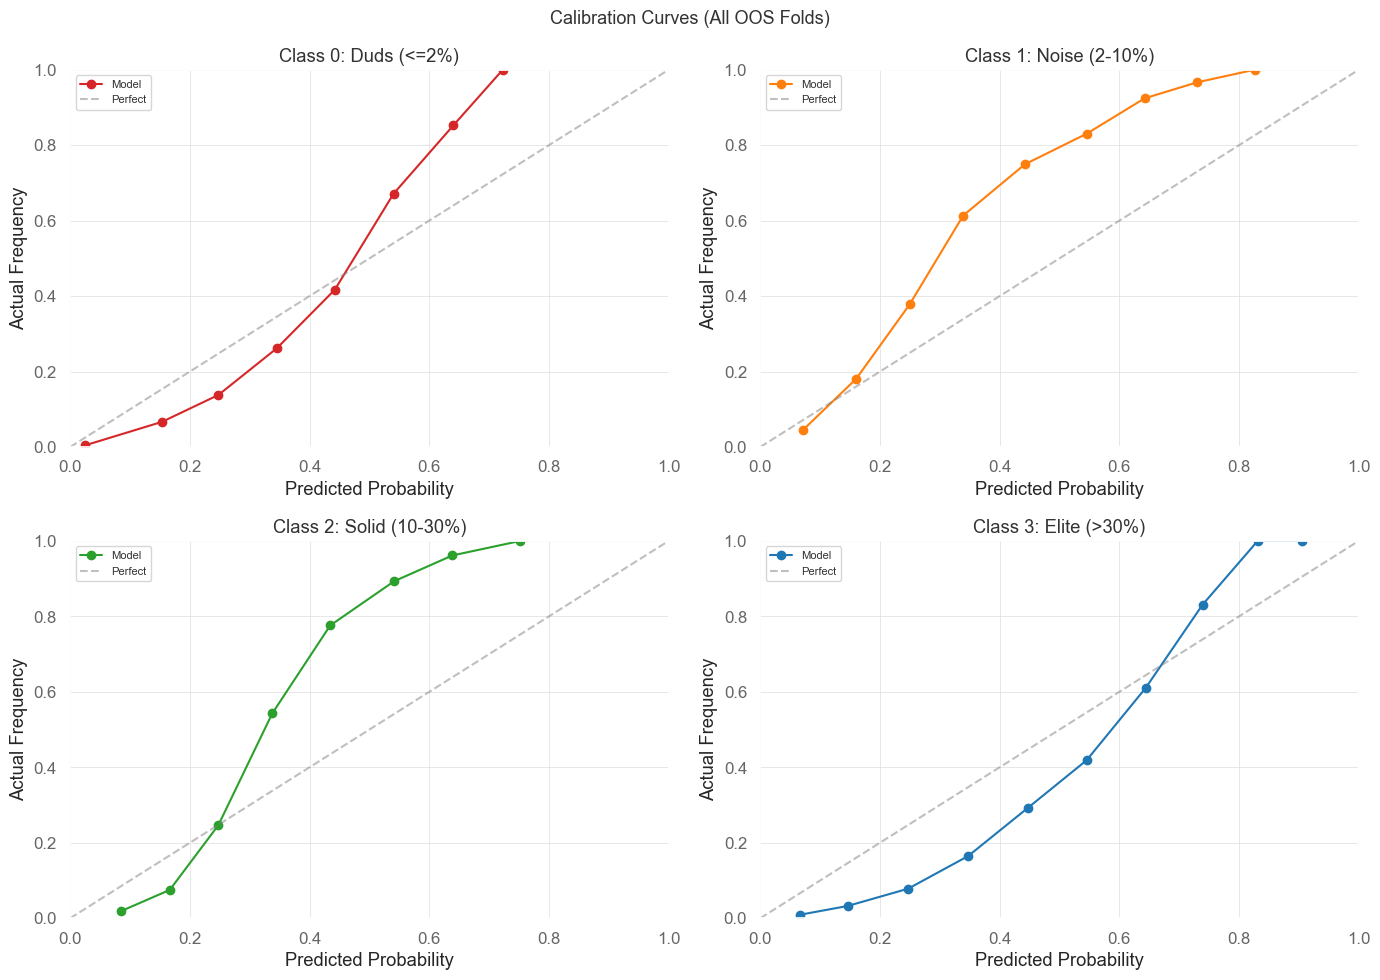

In [106]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for cls_idx, ax in zip(sorted(CLASS_NAMES.keys()), axes.flatten()):
    prob_col = f'prob_class_{cls_idx}'
    actual_binary = (preds_df['target_class'] == cls_idx).astype(int)
    predicted_prob = preds_df[prob_col]

    # Bin predicted probabilities
    bins = np.linspace(0, 1, 11)
    bin_indices = np.digitize(predicted_prob, bins) - 1
    bin_indices = np.clip(bin_indices, 0, len(bins) - 2)

    bin_means = []
    bin_actuals = []
    bin_counts = []
    for b in range(len(bins) - 1):
        mask = bin_indices == b
        if mask.sum() > 0:
            bin_means.append(predicted_prob[mask].mean())
            bin_actuals.append(actual_binary[mask].mean())
            bin_counts.append(mask.sum())

    if len(bin_means) > 0:
        ax.plot(bin_means, bin_actuals, 'o-', color=CLASS_COLORS[cls_idx], label='Model')
        ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5, label='Perfect')
        ax.set_xlabel('Predicted Probability')
        ax.set_ylabel('Actual Frequency')
        ax.set_title(f'{CLASS_NAMES[cls_idx]}')
        ax.legend(fontsize=8)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

plt.suptitle('Calibration Curves (All OOS Folds)', fontsize=13)
plt.tight_layout()
plt.show()


### Summary & Next Steps

In [47]:
prod_stats = models[models['status_flag']=='prod']
prod_acc = prod_stats['accuracy'].iloc[0]
prod_wf1 = prod_stats['weighted_f1'].iloc[0]
prod_mf1 = prod_stats['macro_f1'].iloc[0]
prod_version = prod_stats['version_id'].iloc[0]

proto_acc = prod_result_dict['accuracy']
proto_wf1 = prod_result_dict['weighted_f1']
proto_mf1 = prod_result_dict['macro_f1']

# 3. Print Summary with Deltas
print("=" * 70)
print("PROTOTYPE SUMMARY")
print("=" * 70)
print(f"Dataset:          {len(df):,} rows, {df['ticker'].nunique()} tickers, {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Features:         {len(selected_features)} ({len(CATEGORICAL_FEATURES)} categorical)")
print(f"  - New features: {len(new_feat_added)} new")
print(f"  - Removed features: {len(feat_removed)} removed")
print(f"Walk-Forward:     {len(folds)} folds ({TRAIN_WINDOW}yr train, {TEST_WINDOW}yr test)")

print("\n--- METRICS VS PROD ---")
print(f"Baseline version: {prod_version}")

def format_metric(proto_val, prod_val):
    if pd.isna(prod_val): return f"{proto_val:.3f} (Prod: N/A)"
    delta = proto_val - prod_val
    sign = "+" if delta > 0 else ""
    return f"{proto_val:.3f} (Prod: {prod_val:.3f} | Delta: {sign}{delta:.3f})"
print(f"Mean Accuracy:    {format_metric(proto_acc, prod_acc)}")
print(f"Mean Weighted F1: {format_metric(proto_wf1, prod_wf1)}")
print(f"Mean Macro F1:    {format_metric(proto_mf1, prod_mf1)}")

print("\nPer-Class F1 (mean across folds):")
for cls_idx in sorted(CLASS_NAMES.keys()):
    col = f'f1_class_{cls_idx}'
    if col in results_df.columns:
        print(f"  {CLASS_NAMES[cls_idx]}: {results_df[col].mean():.3f}")

PROTOTYPE SUMMARY
Dataset:          35,536 rows, 2587 tickers, 2003-07-21 to 2026-04-24
Features:         99 (2 categorical)
  - New features: 25 new
  - Removed features: 32 removed
Walk-Forward:     21 folds (3yr train, 1yr test)

--- METRICS VS PROD ---
Baseline version: M01_baseline_v0.1
Mean Accuracy:    0.259 (Prod: 0.670 | Delta: -0.411)
Mean Weighted F1: 0.263 (Prod: 0.582 | Delta: -0.319)
Mean Macro F1:    0.258 (Prod: 0.248 | Delta: +0.010)

Per-Class F1 (mean across folds):
  Class 0: Duds (<=2%): 0.289
  Class 1: Noise (2-10%): 0.427
  Class 2: Solid (10-30%): 0.277
  Class 3: Elite (>30%): 0.199


## Save Model

In [108]:
# ============================================================
# SAVE MODEL FOR BACKTEST
# ============================================================
# Run this after training is complete. Saves the model + metadata
# to models/<name>/ so the backtest infra can load it.

import json, sys
from pathlib import Path
from datetime import datetime

ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

model = fold_models[-2]

MODEL_NAME = 'm01_prototyoe_2003_2026'
MODEL_DIR = ROOT / 'models' / MODEL_NAME
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# 1. Save the XGBoost model
# Replace `model` with your trained variable name (model / booster / etc.)
model_path = MODEL_DIR / 'model.json'
model.save_model(str(model_path))  # works for both Booster and XGBClassifier
print(f"✓ Model saved: {model_path}")

# 2. Save metadata
metadata = {
    'valid_features': selected_features,  # Replace with your feature list variable
    'model_name': MODEL_NAME,
    'saved_at': datetime.now().isoformat(),
    'n_features': len(selected_features),
}
metadata_path = MODEL_DIR / 'metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Metadata saved: {metadata_path} ({len(selected_features)} features)")

print(f"\nReady for backtest — use:")
print(f"  UniverseScorer(m01_path='{model_path}')")


✓ Model saved: C:\Users\Hang\PycharmProjects\quantamental\models\m01_prototyoe_2003_2026\model.json
✓ Metadata saved: C:\Users\Hang\PycharmProjects\quantamental\models\m01_prototyoe_2003_2026\metadata.json (99 features)

Ready for backtest — use:
  UniverseScorer(m01_path='C:\Users\Hang\PycharmProjects\quantamental\models\m01_prototyoe_2003_2026\model.json')


In [109]:
print("\nFormatting Stitched OOS Predictions for Backtrader...")

oos_scores = preds_df.copy()
# Map the probabilities to the format BackTrader expects from UniverseScorer
oos_scores['prob_elite'] = oos_scores['prob_class_3']

# Strategy looks for a 0-100 normalized score. We can just use the Elite probability * 100
oos_scores['normalized_score'] = oos_scores['prob_elite'] * 100

# Strategy looks for trailing ranks. We can rebuild the rankings daily across the stitched dataset
oos_scores['daily_pct_rank'] = oos_scores.groupby('date')['prob_elite'].rank(pct=True)
# Approximate trailing rank (in the real pipeline this is a 10-day rolling, but daily is a good proxy for the notebook)
oos_scores['trailing_pct'] = oos_scores['daily_pct_rank']

# Save this to disk!
oos_scores.to_parquet(Path().resolve() / 'stitched_oos_scores.parquet')

# Next time you run BackTrader, DO NOT call UniverseScorer. 
# Just do: scores_df = pd.read_parquet(Path().resolve() / 'stitched_oos_scores.parquet')



Formatting Stitched OOS Predictions for Backtrader...


Next Steps:
1. Check per-class F1 — is Class 3 (Elite) being recalled?
2. Try SMOTE / cost-sensitive weighting if class imbalance is severe
3. Tune bin edges if class 0 dominates
4. Add SHAP analysis for interpretability
5. Register best model via ModelRegistry if metrics improve

## Backtest

### Set up

In [130]:
# ============================================================
# BACKTEST: Run SEPAHybridV1 from Notebook
# ============================================================
# Paste this into a notebook cell. It will:
# 1. Score the universe from T3 (daily, ~125K rows)
# 2. Run the full BackTrader backtest
# 3. Display QuantStats interactive tearsheet inline
# 4. Show trade log and summary stats
import sys, logging
from pathlib import Path
from datetime import datetime, timedelta
ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

MODEL = 'm01_prototyoe_2003_2026' # 22 24
# MODEL = MODEL_NAME
model_dir = ROOT / 'models' / MODEL
model_path  = str(model_dir / 'model.json')
cal_path  = model_dir / 'calibration.json'
cal_str   = str(cal_path) if cal_path.exists() else None

logging.basicConfig(level=logging.WARNING,
                    format='%(asctime)s | %(levelname)s | %(message)s',
                    datefmt='%H:%M:%S')


In [131]:
# ============================================================
# BACKTEST HELPER
# ============================================================
%load_ext autoreload
%autoreload 2

def reload_backtest():
    """Reload all backtest modules (call after editing source)."""
    import src.backtest.runner, src.backtest.sepa_strategy, src.backtest.universe_scorer
    importlib.reload(src.backtest.universe_scorer)
    importlib.reload(src.backtest.runner)
    importlib.reload(src.backtest.sepa_strategy)

reload_backtest()
from src.backtest.runner import SEPABacktestRunner
from src.backtest.sepa_strategy import SEPAHybridV1, SEPAFlatV1
from src.backtest.universe_scorer import UniverseScorer

def run_backtest(
    start: str,
    end: str,
    strategy=SEPAFlatV1,
    model: str = 'models/m01_prototype/model.json',
    cash: float = 100_000,
    warmup_months: int = 6,
    max_tickers: int = None,
    **strategy_overrides,
):
    """
    Run a full backtest: score → setup → run → report.
    
    Args:
        start: Eval start date 'YYYY-MM-DD' (BackTrader starts warmup_months earlier)
        end: End date 'YYYY-MM-DD'
        strategy: Strategy class (SEPAFlatV1, SEPAHybridV1, etc.)
        model: Path to model.json
        cash: Initial capital
        warmup_months: Months of warmup before start (for SMA50 etc.)
        max_tickers: Cap tickers for smoke testing
        **strategy_overrides: Any strategy params to override (e.g., min_prob_elite=0.30)
    
    Returns:
        (metrics, runner, trade_df)
    """
    eval_start = start
    bt_start = (datetime.strptime(start, '%Y-%m-%d') - timedelta(days=warmup_months * 30)).strftime('%Y-%m-%d')
    score_start = (datetime.strptime(bt_start, '%Y-%m-%d') - timedelta(days=365)).strftime('%Y-%m-%d')
    
    # 1. Score
    print(f"[1/3] Scoring ({score_start} → {end})...")
    scorer = UniverseScorer(m01_path=model)
    scores_df = scorer.score_from_t3(score_start, end)
    print(f"      {len(scores_df):,} rows, {scores_df['ticker'].nunique()} tickers")
    
    # 2. Setup
    print(f"[2/3] Setting up ({bt_start} → {end}, eval from {eval_start})...")
    runner = SEPABacktestRunner(start_date=bt_start, end_date=end, initial_cash=cash)
    runner.setup(scores_df=scores_df, max_tickers=max_tickers)
    
    runner.cerebro.strats = []
    runner.cerebro.addstrategy(strategy, scores_df=scores_df, **strategy_overrides)
    
    # 3. Run
    print(f"[3/3] Running backtest...")
    metrics = runner.run()
    runner.print_results(metrics)
    
    # 4. Trade analysis (eval window only)
    trade_df = runner.get_trade_dataframe()
    if trade_df is not None and len(trade_df) > 0:
        trade_df['entry_date'] = pd.to_datetime(trade_df['entry_date'])
        eval_trades = trade_df[trade_df['entry_date'] >= eval_start]
        
        if len(eval_trades) > 0:
            wins = eval_trades[eval_trades['pnl_percent'] > 0]
            losses = eval_trades[eval_trades['pnl_percent'] <= 0]
            pf = abs(wins['pnl_percent'].sum() / losses['pnl_percent'].sum()) if len(losses) and losses['pnl_percent'].sum() != 0 else float('inf')
            
            print(f"\n{'='*50}")
            print(f"EVAL WINDOW: {eval_start} → {end}")
            print(f"{'='*50}")
            print(f"  Trades:         {len(eval_trades)}")
            print(f"  Win Rate:       {len(wins)/len(eval_trades)*100:.1f}%")
            print(f"  Avg PnL:        {eval_trades['pnl_percent'].mean():+.2f}%")
            print(f"  Median PnL:     {eval_trades['pnl_percent'].median():+.2f}%")
            print(f"  Profit Factor:  {pf:.2f}")  

    return metrics, runner, trade_df


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Run Backtest

[1/3] Scoring (2018-07-05 → 2025-12-31)...


23:37:05 | WARNING | No calibration table at models\m01_calibration.json


      46,455 rows, 2592 tickers
[2/3] Setting up (2019-07-05 → 2025-12-31, eval from 2020-01-01)...
[3/3] Running backtest...


23:41:22 | WARNING | Order failed for INOD: 7



SEPA HYBRID V1 BACKTEST RESULTS

Period: 2019-07-05 to 2025-12-31
Starting Capital: $100,000

--- PERFORMANCE ---
Final Value:     $198,958.09
Total Return:    +98.96%
Sharpe Ratio:    0.7262313818703577
SQN:             2.4624369564318194

--- RISK ---
Max Drawdown:    17.17%
Max DD Length:   275 bars

--- TRADES ---
Total Trades:    299
Win Rate:        44.5%
Won/Lost:        133/156
Net Profit:      $104,924.10

--- EXPOSURE ---
Avg Exposure:    48.6%
Max Exposure:    99.8%
Time Invested:   94.7%
Avg Positions:   5.0

--- SIGNAL REJECTIONS ---
Total Rejected:  562
  - no_data: 249
  - already_holding: 229
  - no_slots: 69


EVAL WINDOW: 2020-01-01 → 2025-12-31
  Trades:         289
  Win Rate:       45.3%
  Avg PnL:        +3.25%
  Median PnL:     -4.85%
  Profit Factor:  1.50

QUANTSTATS TEARSHEET
CAGR:           14.72%
Sharpe:         0.92
Sortino:        1.42
Max Drawdown:   -17.17%
Calmar:         0.86
Win Rate:       52.1%



Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               2021-03-16   2021-03-16
End Period                 2025-12-31   2025-12-31
Risk-Free Rate             0.0%         0.0%
Time in Market             97.0%        93.0%

Cumulative Return          84.28%       98.96%
CAGR﹪                     13.09%       14.85%

Sharpe                     0.82         0.93
Prob. Sharpe Ratio         96.61%       98.16%
Smart Sharpe               0.79         0.9
Sortino                    1.18         1.42
Smart Sortino              1.15         1.38
Sortino/√2                 0.84         1.01
Smart Sortino/√2           0.81         0.98
Omega                      1.16         1.19

Max Drawdown               -24.5%       -17.17%
Max DD Date                2022-10-12   2021

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2021-03-18,2021-09-30,2022-04-06,385,-17.166271,-16.148412
2,2024-02-29,2024-08-05,2024-10-17,232,-15.378186,-13.836561
3,2024-12-27,2025-04-07,2025-06-13,169,-14.509660,-14.271298
4,2023-01-25,2023-03-13,2023-06-01,128,-10.132833,-9.349787
5,2023-12-27,2024-01-19,2024-02-13,49,-8.779736,-8.591278


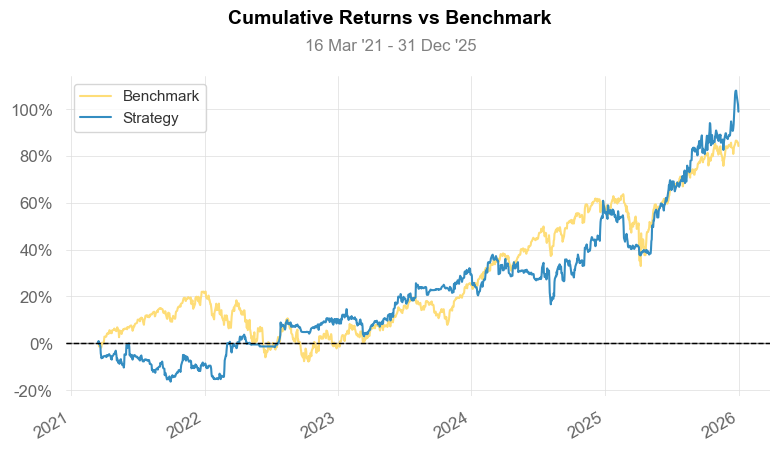

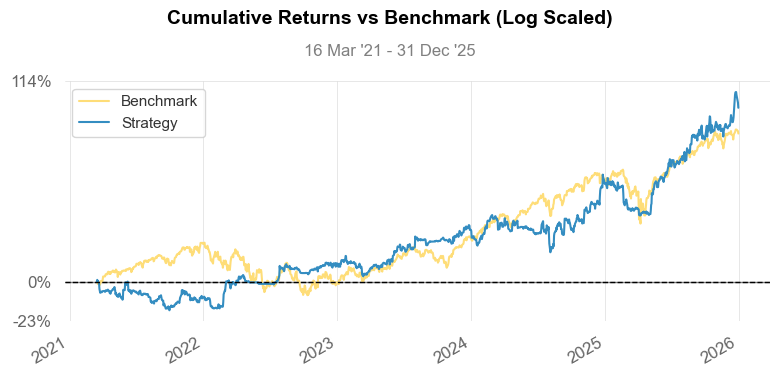

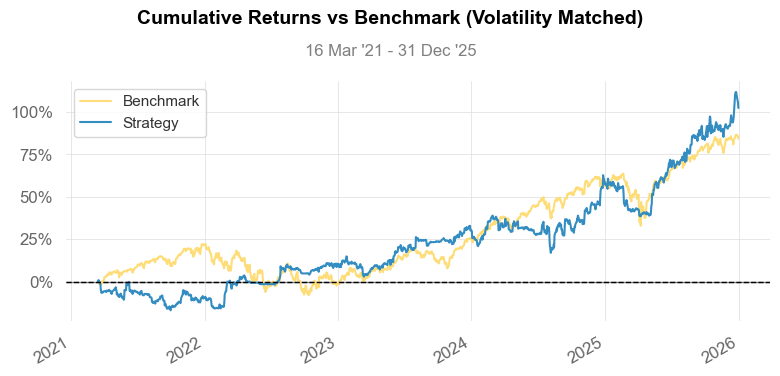

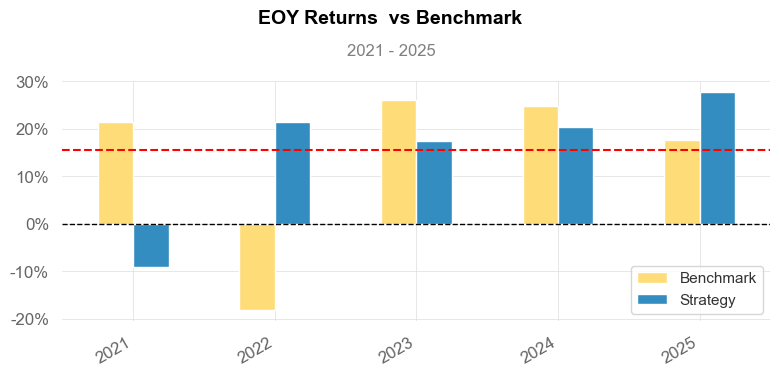

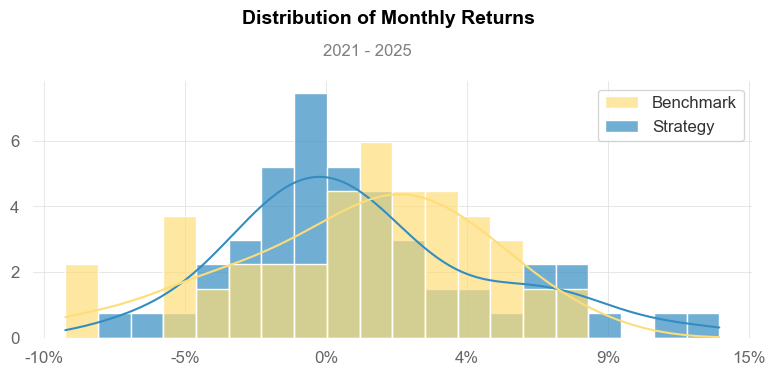

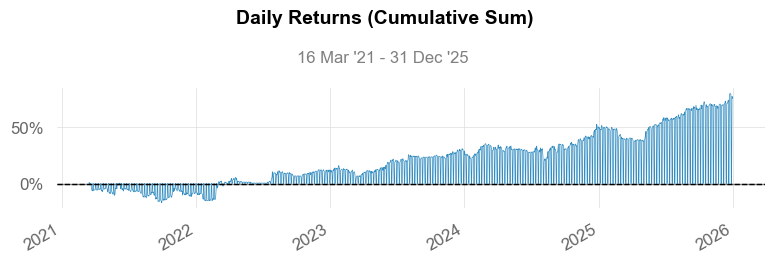

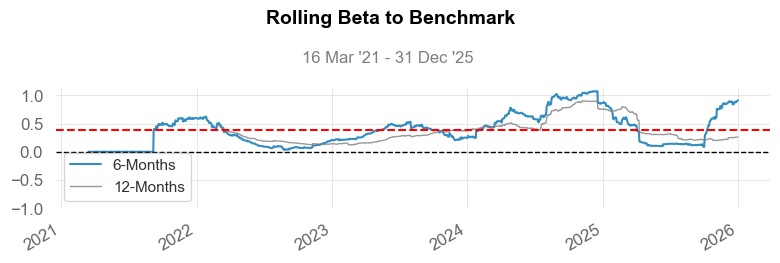

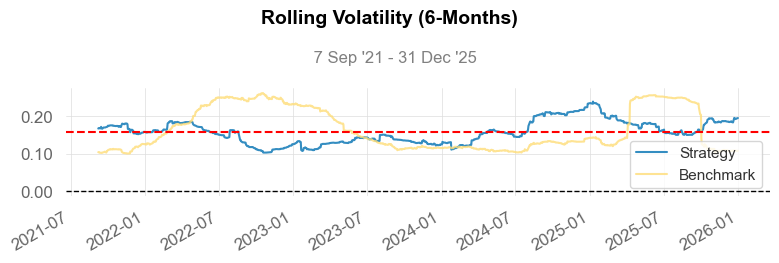

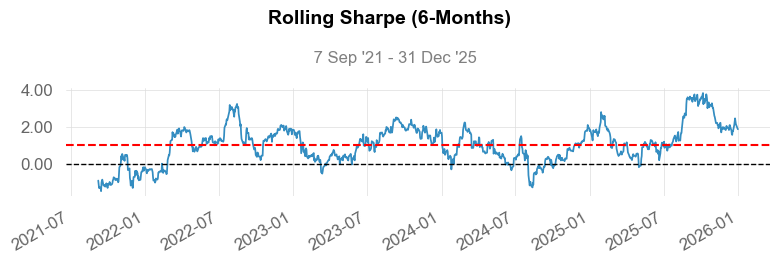

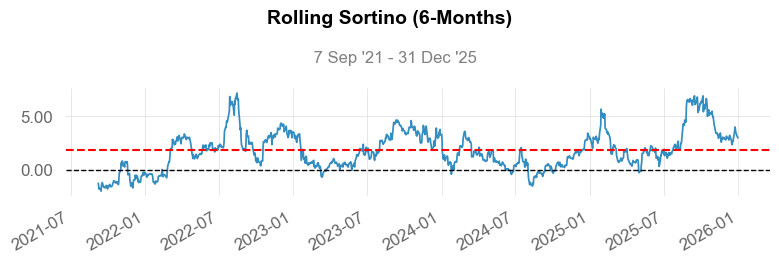

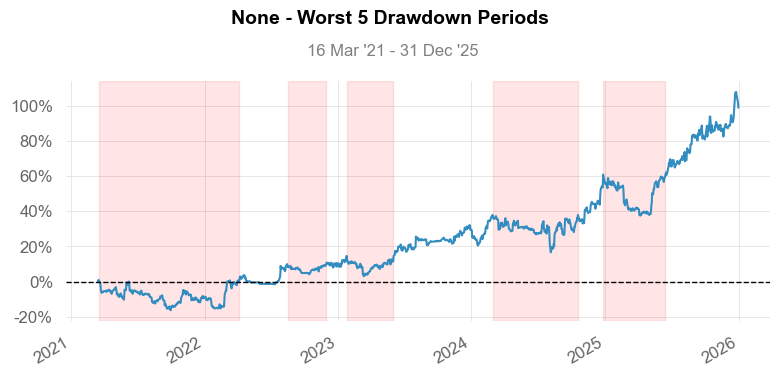

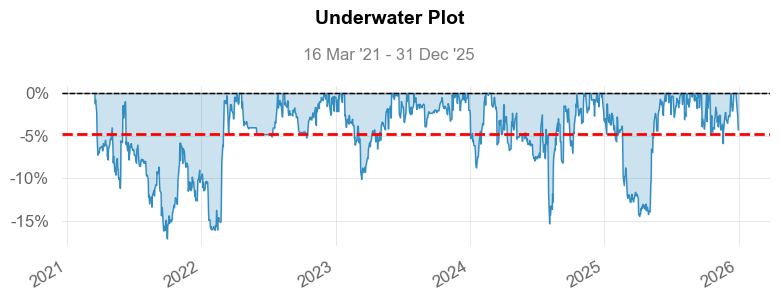

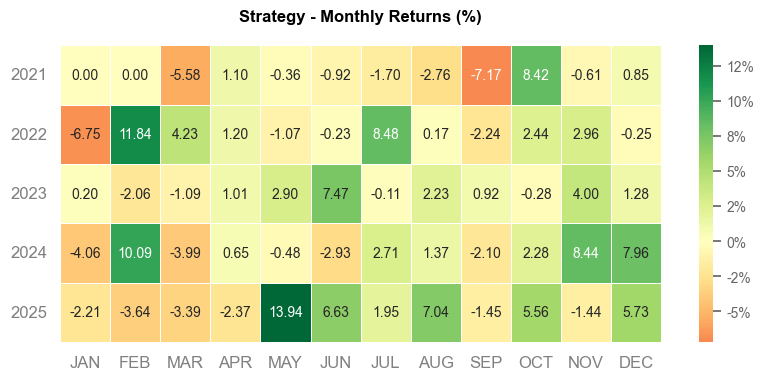

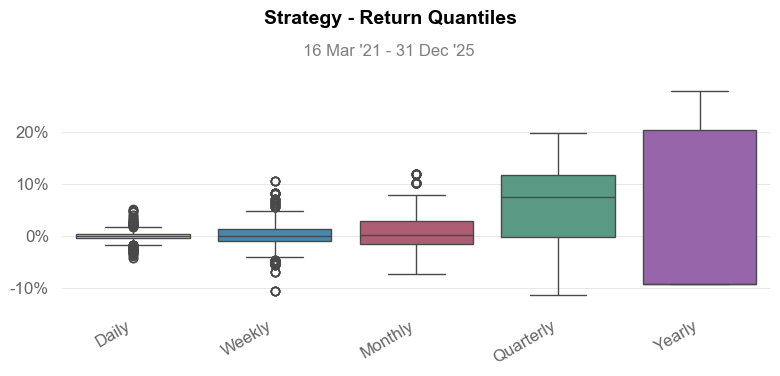

In [132]:
# Basic run
# metrics, runner, trades = run_backtest('2020-01-01', '2025-01-01')

# Different date range
# metrics, runner, trades = run_backtest('2010-01-01', '2015-01-01')

# Different strategy
# metrics, runner, trades = run_backtest('2020-01-01', '2025-01-01', strategy=SEPAFlatV1, model=m01_path)

# Override specific params
# metrics, runner, trades = run_backtest(
#     '2020-01-01', '2025-01-01',
#     min_prob_elite=0.50,
#     max_stop_pct=0.20,
#     sma_exit_period=100,
#     model=model_path
# )

# Smoke test (fast)
# metrics, runner, trades = run_backtest('2024-01-01', '2024-06-30', max_tickers=50)

# 1. Clear any old strategies (crucial if running in a Jupyter cell multiple times)
# runner.cerebro.strats = []
# 2. Define the exact parameters you want to override for this run
SWEEP_BEST = {
    'min_prob_elite': 0.5, 
    'stop_loss_pct': 0.2,  
    'sma_exit_period': 100,
}
strategy_kwargs = {
 # Overrides from the vectorized sweep
    'min_prob_elite': SWEEP_BEST['min_prob_elite'],
    'max_stop_pct': SWEEP_BEST['stop_loss_pct'],
    'sma_exit_period': SWEEP_BEST['sma_exit_period'],
    
    # Static parameters you want to enforce
    'min_score': 30,               
    'rank_by': 'trailing',
    'min_price': 5.0,
    'cooldown_days': 3,
    'warmup_days': 10,
    'atr_stop_mult': 2.0,                           
    'atr_target1_mult': 3.0,       
    'min_target1_pct': 0.15,
    'atr_target2_add': 2.0,
    
    # Use Hybrid mode's regime sizing
    'sizing_mode': 'equal_weight',
    'regime_max_pos': {0:0, 1:10, 2:10, 3:10, 4:10},
    # 'regime_sizes': {0:0.0, 1:0.1, 2:0.1, 3:0.1, 4:0.10},
}

# 3. Add the strategy to cerebro
# runner.cerebro.addstrategy(SEPAHybridV1, **strategy_kwargs)

metrics, runner, trades = run_backtest('2020-01-01', '2025-12-31', strategy=SEPAHybridV1, model=model_path, **strategy_kwargs)

# QuantStats tearsheet after any run
import quantstats as qs

equity_df = runner.get_equity_curve_dataframe()
if equity_df is not None and len(equity_df) > 2:
    returns = equity_df['value'].pct_change().dropna()
    returns.index = pd.to_datetime(returns.index)
    returns.index.name = None  # QuantStats requirement
    print(f"\n{'='*60}")
    print("QUANTSTATS TEARSHEET")
    print(f"{'='*60}")
    qs.extend_pandas()
    # Show key metrics inline
    print(f"CAGR:           {qs.stats.cagr(returns)*100:.2f}%")
    print(f"Sharpe:         {qs.stats.sharpe(returns):.2f}")
    print(f"Sortino:        {qs.stats.sortino(returns):.2f}")
    print(f"Max Drawdown:   {qs.stats.max_drawdown(returns)*100:.2f}%")
    print(f"Calmar:         {qs.stats.calmar(returns):.2f}")
    print(f"Win Rate:       {qs.stats.win_rate(returns)*100:.1f}%")
    
    # Full interactive HTML tearsheet (renders in notebook)
    qs.reports.full(returns, benchmark='SPY', output=None, download_filename=None)


<Axes: title={'center': 'Equity vs High Water Mark'}, xlabel='date'>

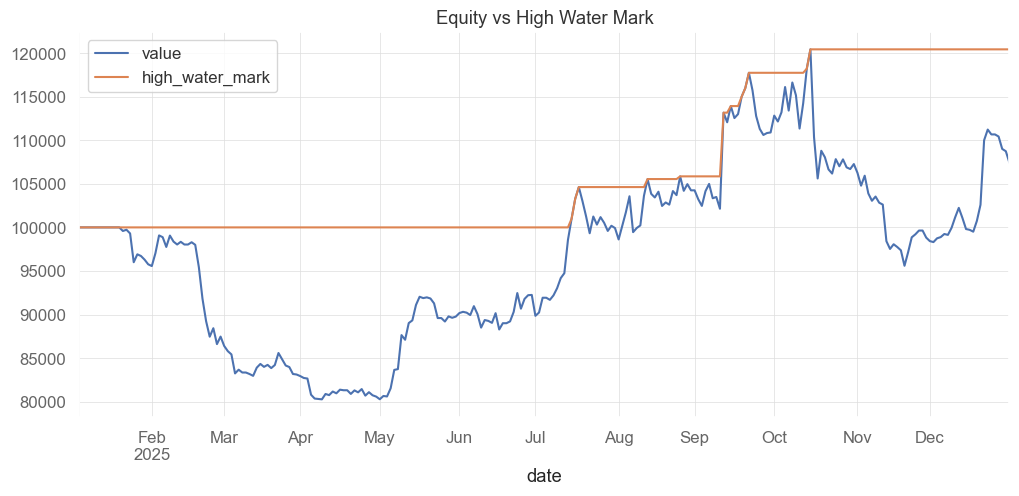

In [125]:
equity_df = runner.get_equity_curve_dataframe()
equity_df['high_water_mark'] = equity_df['value'].cummax()
equity_df['drawdown'] = (equity_df['value'] - equity_df['high_water_mark']) / equity_df['high_water_mark']

# Find the period where the drawdown was active (where it's less than 0)
in_drawdown = equity_df[equity_df['drawdown'] < 0]

# Plot the equity curve alongside the high water mark
equity_df[['value', 'high_water_mark']].plot(figsize=(12, 5), title="Equity vs High Water Mark")


## (Optional) Parameter Sweep

In [135]:
import itertools
import pandas as pd
import quantstats as qs
from src.backtest.vectorized_backtest import VectorizedSEPABacktest

GRID = {
    'min_prob_elite':        [0.1, 0.5, 0.8],
    'stop_loss_pct':         [0.10, 0.15,0.2,0.25],
    'sma_exit_period':       [20, 100],
    'max_positions_per_day': [3, 8, 10],
}

FIXED = dict(
    model_path=model_path,
    start_date='2020-01-01',
    end_date='2025-01-01',
    ranking_lookback_days=10,
    warmup_days=10,
    initial_cash=100_000,
    position_size_pct=0.10,
    max_hold_days=252,
)

keys = list(GRID.keys())
combos = list(itertools.product(*GRID.values()))
print(f"Running {len(combos)} combos...\n")

results = []
for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    vbt = VectorizedSEPABacktest(**FIXED, **params)
    trades = vbt.run()
    
    if trades.empty or len(trades) < 5:
        results.append({**params, 'n_trades': len(trades), 
                        'total_return': 0, 'sharpe': 0, 'max_dd': 0,
                        'win_rate': 0, 'avg_pnl': 0, 'profit_factor': 0})
        continue
    
    # Trade-level stats
    wins = trades[trades['pnl_pct'] > 0]
    losses = trades[trades['pnl_pct'] <= 0]
    pf = abs(wins['pnl_pct'].sum() / losses['pnl_pct'].sum()) if len(losses) and losses['pnl_pct'].sum() != 0 else float('inf')
    
    # Portfolio-level stats via equity curve
    equity = vbt.equity_curve(trades)
    returns = equity.pct_change().dropna()
    
    total_ret = (equity.iloc[-1] - equity.iloc[0]) / equity.iloc[0] * 100
    sharpe = qs.stats.sharpe(returns) if len(returns) > 10 else 0
    max_dd = qs.stats.max_drawdown(returns) * 100 if len(returns) > 10 else 0
    
    row = {
        **params,
        'n_trades': len(trades),
        'win_rate': len(wins) / len(trades),
        'avg_pnl': trades['pnl_pct'].mean(),
        'profit_factor': pf,
        'total_return': total_ret,
        'sharpe': sharpe,
        'max_dd': max_dd,
    }
    results.append(row)
    print(f"[{i+1}/{len(combos)}] "
          f"elite={params['min_prob_elite']} stop={params['stop_loss_pct']} "
          f"sma={params['sma_exit_period']} pos={params['max_positions_per_day']}  →  "
          f"trades={len(trades):3d}  return={total_ret:+.1f}%  "
          f"sharpe={sharpe:.2f}  maxDD={max_dd:.1f}%  PF={pf:.2f}")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('sharpe', ascending=False)

print(f"\n{'='*100}")
print("SWEEP RESULTS (sorted by Sharpe)")
print(f"{'='*100}")
display(results_df.style.format({
    'win_rate': '{:.1%}', 'avg_pnl': '{:+.2%}', 'profit_factor': '{:.2f}',
    'total_return': '{:+.1f}%', 'sharpe': '{:.2f}', 'max_dd': '{:.1f}%'
}))


Running 72 combos...



23:51:45 | WARNING | No calibration table at None
23:51:46 | WARNING | Missing features: ['inventory_vs_sales_spread', 'peg_adjusted_1']


XGBoostError: [23:51:46] C:\actions-runner\_work\xgboost\xgboost\src\data\../data/cat_container.h:28: Invalid new DataFrame input for the: 49th feature (0-based). The data type doesn't match the one used in the training dataset. Both should be either numeric or categorical. For a categorical feature, the index type must match between the training and test set.

In [ ]:
# ============================================================
# ENHANCED SWEEP — tail-aware per-trade metrics
# ============================================================
import itertools
import numpy as np
import pandas as pd
from src.backtest.vectorized_backtest import VectorizedSEPABacktest

GRID = {
    'min_prob_elite':        [0.10, 0.5],
    'stop_loss_pct':         [0.10, 0.20],
    'sma_exit_period':       [20, 100],
    'max_positions_per_day': [3, 10],
}

FIXED = dict(
    model_path=m01_path,
    start_date='2020-01-01',
    end_date='2025-01-01',
    ranking_lookback_days=10,
    warmup_days=10,
    initial_cash=100_000,
    position_size_pct=0.10,
    max_hold_days=252,
)

keys = list(GRID.keys())
combos = list(itertools.product(*GRID.values()))
print(f"Running {len(combos)} combos...\n")

results = []
for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    vbt = VectorizedSEPABacktest(**FIXED, **params)
    trades = vbt.run()
    
    if trades.empty or len(trades) < 5:
        results.append({**params, 'n_trades': 0})
        continue
    
    pnl = trades['pnl_pct']
    wins = pnl[pnl > 0]
    losses = pnl[pnl <= 0]
    
    # --- Core stats ---
    win_rate = len(wins) / len(trades)
    avg_pnl = pnl.mean()
    median_pnl = pnl.median()
    total_pnl_sum = pnl.sum()
    
    # --- Portfolio-level approximation ---
    # Each trade uses position_size_pct of capital
    # Approximate portfolio return = sum of (pnl × size_pct)
    approx_portfolio_return = total_pnl_sum * FIXED['position_size_pct'] * 100
    
    # --- Profit factor ---
    pf = abs(wins.sum() / losses.sum()) if len(losses) and losses.sum() != 0 else float('inf')
    
    # --- Expectancy (avg $ per trade on $10K position) ---
    expectancy = avg_pnl * FIXED['position_size_pct'] * FIXED['initial_cash']
    
    # --- Tail metrics ---
    pct_90 = pnl.quantile(0.90)       # 90th percentile trade
    pct_10 = pnl.quantile(0.10)       # 10th percentile trade
    tail_ratio = abs(pct_90 / pct_10) if pct_10 != 0 else float('inf')
    
    # Big winner contribution
    big_winners = pnl[pnl > 0.30]     # trades with >30% gain
    pct_from_big = big_winners.sum() / total_pnl_sum * 100 if total_pnl_sum > 0 else 0
    n_big = len(big_winners)
    
    # Skewness (positive = right tail = good for momentum)
    skew = pnl.skew()
    
    row = {
        **params,
        'n_trades': len(trades),
        'win_rate': win_rate,
        'avg_pnl': avg_pnl,
        'median_pnl': median_pnl,
        'total_pnl_sum': total_pnl_sum,
        'approx_return': approx_portfolio_return,
        'profit_factor': pf,
        'expectancy_$': expectancy,
        'p90': pct_90,
        'p10': pct_10,
        'tail_ratio': tail_ratio,
        'n_big_wins': n_big,
        'pct_from_big': pct_from_big,
        'skew': skew,
        'avg_hold': trades['holding_days'].mean(),
    }
    results.append(row)
    
    print(f"[{i+1}/{len(combos)}] "
          f"elite={params['min_prob_elite']:.2f} stop={params['stop_loss_pct']} sma={params['sma_exit_period']}  →  "
          f"n={len(trades):4d}  wr={win_rate:.0%}  "
          f"total_pnl={total_pnl_sum:+.0f}%  ≈return={approx_portfolio_return:+.0f}%  "
          f"PF={pf:.2f}  big_wins={n_big}({pct_from_big:.0f}%)")

# --- RESULTS TABLE ---
results_df = pd.DataFrame(results)
results_df = results_df[results_df['n_trades'] >= 5]  # Filter empties
results_df = results_df.sort_values('total_pnl_sum', ascending=False)

print(f"\n{'='*110}")
print("SWEEP RESULTS — sorted by total PnL sum")
print(f"{'='*110}")
display(results_df[[
    *keys, 'n_trades', 'win_rate', 'avg_pnl', 'median_pnl', 
    'total_pnl_sum', 'approx_return', 'profit_factor',
    'n_big_wins', 'pct_from_big', 'skew', 'tail_ratio',
]].style.format({
    'win_rate': '{:.0%}', 'avg_pnl': '{:+.1%}', 'median_pnl': '{:+.1%}',
    'total_pnl_sum': '{:+.0f}%', 'approx_return': '{:+.0f}%',
    'profit_factor': '{:.2f}', 'pct_from_big': '{:.0f}%',
    'skew': '{:.2f}', 'tail_ratio': '{:.2f}',
}))


In [ ]:
# ============================================================
# VALIDATE SWEEP WINNER IN BACKTRADER
# ============================================================
# Translates vectorized sweep params → BackTrader strategy params

import importlib
import src.backtest.runner, src.backtest.sepa_strategy
importlib.reload(src.backtest.runner)
importlib.reload(src.backtest.sepa_strategy)
from src.backtest.runner import SEPABacktestRunner
from src.backtest.sepa_strategy import SEPAHybridV1, SEPAFlatV1

# --- YOUR SWEEP WINNER ---
SWEEP_BEST = {
    'min_prob_elite': 0.5,    # From sweep
    'stop_loss_pct': 0.2,     # From sweep
    'sma_exit_period': 100,     # From sweep
}

# --- TRANSLATED TO BACKTRADER ---
BT_START     = '2019-06-01'   # 6-month warmup for SMA50
END_DATE     = '2025-01-01'
EVAL_START   = '2020-01-01'
INITIAL_CASH = 100_000

runner = SEPABacktestRunner(
    start_date=BT_START,
    end_date=END_DATE,
    initial_cash=INITIAL_CASH,
)
runner.setup(scores_df=scores_df)

# Override strategy with sweep-winner params
runner.cerebro.strats = []
runner.cerebro.addstrategy(
    SEPAFlatV1,
    scores_df=scores_df,
    
    # === ENTRY (from sweep) ===
    min_prob_elite=SWEEP_BEST['min_prob_elite'],
    min_score=30,               # Keep safety floor
    rank_by='trailing',
    min_price=5.0,
    cooldown_days=3,
    warmup_days=10,
    
    # === EXIT (bridged from sweep) ===
    max_stop_pct=SWEEP_BEST['stop_loss_pct'],   # Cap ATR stop at sweep's flat %
    atr_stop_mult=2.0,                           # Keep ATR-based, capped by above
    sma_exit_period=SWEEP_BEST['sma_exit_period'],
    
    # === TARGETS (BT-only, not in sweep) ===
    atr_target1_mult=3.0,       # Keep defaults
    min_target1_pct=0.15,
    atr_target2_add=2.0,
    
    # === SIZING (BT-only) ===
    sizing_mode='regime',
    regime_max_pos={0:0, 1:4, 2:8, 3:10, 4:12},
    regime_sizes={0:0.0, 1:0.025, 2:0.05, 3:0.075, 4:0.10},
)

print("Running BackTrader validation...")
metrics = runner.run()
runner.print_results(metrics)

# --- COMPARE WITH SWEEP ---
import pandas as pd
trade_df = runner.get_trade_dataframe()
if trade_df is not None:
    trade_df['entry_date'] = pd.to_datetime(trade_df['entry_date'])
    eval_trades = trade_df[trade_df['entry_date'] >= EVAL_START]
    
    if len(eval_trades) > 0:
        wins = eval_trades[eval_trades['pnl_percent'] > 0]
        losses = eval_trades[eval_trades['pnl_percent'] <= 0]
        
        print(f"\n{'='*60}")
        print(f"COMPARISON (eval window: {EVAL_START} onwards)")
        print(f"{'='*60}")
        print(f"{'Metric':<25} {'Vectorized':<15} {'BackTrader':<15}")
        print(f"{'-'*55}")
        print(f"{'Trades':<25} {'915':<15} {len(eval_trades):<15}")
        print(f"{'Win Rate':<25} {'33.0%':<15} {len(wins)/len(eval_trades)*100:.1f}%")
        print(f"{'Avg PnL/trade':<25} {'+4.09%':<15} {eval_trades['pnl_percent'].mean():+.2f}%")
        print(f"{'Median PnL':<25} {'—':<15} {eval_trades['pnl_percent'].median():+.2f}%")
        total_pnl = eval_trades['pnl_percent'].sum()
        print(f"{'Total PnL Sum':<25} {'—':<15} {total_pnl:+.0f}%")
        pf = abs(wins['pnl_percent'].sum() / losses['pnl_percent'].sum()) if len(losses) else float('inf')
        print(f"{'Profit Factor':<25} {'1.63':<15} {pf:.2f}")
        tr = metrics.get('total_return', 0)
        sr = metrics.get('sharpe_ratio', 'N/A')
        md = metrics.get('max_drawdown', 0)
        print(f"{'Portfolio Return':<25} {'—':<15} {tr:+.1f}%")
        print(f"{'Sharpe':<25} {'—':<15} {sr}")
        print(f"{'Max Drawdown':<25} {'—':<15} {md:.1f}%")

